# E-Nose Gas Classification — Sensor Drift Robustness Study

## Dataset
This notebook uses the **UCI Gas Sensor Array Drift Dataset**:
- Source: https://archive.ics.uci.edu/dataset/224/gas+sensor+array+drift+dataset
- Original reference: Vergara, A., Vembu, S., Ayhan, T., Ryan, M.A., Homer, M.L.,
  Huerta, R. (2012). *Chemical gas sensor drift compensation using classifier
  ensembles*. Sensors and Actuators B: Chemical.
- 6 gas classes (Ethanol, Ethylene, Ammonia, Acetaldehyde, Acetone, Toluene),
  collected across 10 batches spanning ~36 months.
- Each sample: 128 features = 16 sensors × 8 precomputed descriptors
  (steady-state value, max, min, mean, variance, rising slope, AUC, recovery
  slope). **These 16 sensor positions are structural, not timesteps** — no
  temporal ordering exists within a sample.

## Setup instructions
1. Download the 10 batch files (`batch1.dat` – `batch10.dat`) from the UCI
   link above and extract them locally.
2. Run this notebook in Google Colab (or a local Jupyter environment with
   the packages listed in `requirements.txt`, see Part B below).
3. When prompted by the "UPLOAD DATASET" cell, select all 10 `batch*.dat`
   files at once.
4. Run all cells top to bottom (**Runtime → Restart runtime → Run all**).
   Do not skip cells or run out of order — later cells depend on scalers
   and models fit in earlier cells (e.g. `scaler_mixed`, `scaler_drift`,
   `X_train_lstm_drift`).

## Expected input filenames
batch1.dat
batch2.dat
batch3.dat
batch4.dat
batch5.dat
batch6.dat
batch7.dat
batch8.dat
batch9.dat
batch10.dat

Each file is in LIBSVM format: `<label> <index>:<value> <index>:<value> ...`

## Reproducibility
- Global seed: `SEED = 42`, fixed via `set_seed()` before every training run.
- Neural models (LSTM, Transformer) are trained with **3 repeated runs**
  (seeds 42, 43, 44) and results are reported as mean ± std, not a
  test-set-selected "best run" (see robustness notes in the drift cells).

In [1]:
# ============================================================
# PINNED PACKAGE VERSIONS (for reproducibility)
# ============================================================
# packages mid-session (which requires a runtime restart to resolve
# and breaks a single clean "Run all").
!pip install -q reservoirpy==0.3.11 skl2onnx==1.17.0 onnx==1.16.2 onnxruntime==1.19.2 onnxscript

print("Reservoir/ONNX dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.4/298.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.0 MB/s eta 0:00:00
Reservoir/ONNX dependencies installed.


In [2]:
# ============================================================
# LOAD LIBRARIES
# ============================================================
import os
import time
import random
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
import json
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
import subprocess
with open("results/environment_versions.txt", "w") as f:
    f.write(subprocess.run(["pip", "freeze"], capture_output=True, text=True).stdout)
print("Captured environment package versions to results/environment_versions.txt")

Captured environment package versions to results/environment_versions.txt


In [4]:
# ============================================================
# SELECT COMPUTING DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
# ============================================================
# UPLOAD DATASET
# ============================================================
from google.colab import files

print("Select all 10 batch files when the dialog opens...")
uploaded = files.upload()
print(f"{len(uploaded)} files uploaded")
print("Files:", list(uploaded.keys()))

Select all 10 batch files when the dialog opens...


Saving batch1.dat to batch1.dat
Saving batch2.dat to batch2.dat
Saving batch3.dat to batch3.dat
Saving batch4.dat to batch4.dat
Saving batch5.dat to batch5.dat
Saving batch6.dat to batch6.dat
Saving batch7.dat to batch7.dat
Saving batch8.dat to batch8.dat
Saving batch9.dat to batch9.dat
Saving batch10.dat to batch10.dat
10 files uploaded
Files: ['batch1.dat', 'batch2.dat', 'batch3.dat', 'batch4.dat', 'batch5.dat', 'batch6.dat', 'batch7.dat', 'batch8.dat', 'batch9.dat', 'batch10.dat']


In [6]:
# ============================================================
# LOAD FUNCTION
# ============================================================
def load_libsvm(filename, n_features=128):
    """
    Reads one batch file.
    128 features = 16 sensors x 8 descriptors (NOT timesteps).
    """
    X, y = [], []
    with open(filename) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 0:
                continue
            y.append(int(float(parts[0])))
            row = np.zeros(n_features)
            for item in parts[1:]:
                if ':' in item:
                    idx, val = item.split(':')
                    row[int(idx) - 1] = float(val)
            X.append(row)
    return np.array(X), np.array(y)

print("LIBSVM loading function defined.")

LIBSVM loading function defined.


In [7]:
# ============================================================
# LOAD ALL 10 BATCHES
# ============================================================
print("Loading batch files...")
print("-" * 50)

X_all, y_all, batch_ids = [], [], []

for i in range(1, 11):
    filename = f"batch{i}.dat"
    X_batch, y_batch = load_libsvm(filename)
    X_all.append(X_batch)
    y_all.append(y_batch)
    batch_ids.append(np.full(len(y_batch), i))
    print(f"Batch {i:2d} -> {len(y_batch):4d} samples loaded")

X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)
batch_ids = np.concatenate(batch_ids)

print("-" * 50)
print("ALL BATCHES LOADED")
print(f"Total samples : {X_all.shape[0]}")
print(f"Total features: {X_all.shape[1]}")
print(f"Unique classes: {np.unique(y_all)}")

np.save("X_all.npy", X_all)
np.save("y_all.npy", y_all)
np.save("batch_ids.npy", batch_ids)

Loading batch files...
--------------------------------------------------
Batch  1 ->  445 samples loaded
Batch  2 -> 1244 samples loaded
Batch  3 -> 1586 samples loaded
Batch  4 ->  161 samples loaded
Batch  5 ->  197 samples loaded
Batch  6 -> 2300 samples loaded
Batch  7 -> 3613 samples loaded
Batch  8 ->  294 samples loaded
Batch  9 ->  470 samples loaded
Batch 10 -> 3600 samples loaded
--------------------------------------------------
ALL BATCHES LOADED
Total samples : 13910
Total features: 128
Unique classes: [1 2 3 4 5 6]


In [8]:
# ============================================================
# DEFINE GAS CLASSES
# ============================================================
gas_names_dict = {
    1: "Ethanol", 2: "Ethylene", 3: "Ammonia",
    4: "Acetaldehyde", 5: "Acetone", 6: "Toluene"
}
GAS_NAMES = ["Ethanol", "Ethylene", "Ammonia", "Acetaldehyde", "Acetone", "Toluene"]

print("Gas classes defined:")
print(GAS_NAMES)

Gas classes defined:
['Ethanol', 'Ethylene', 'Ammonia', 'Acetaldehyde', 'Acetone', 'Toluene']


In [9]:
# ============================================================
# DATA QUALITY CHECK
# ============================================================
df_check = pd.DataFrame(X_all)
n_missing = df_check.isnull().sum().sum()
n_inf = np.isinf(X_all).sum()
n_duplicates = df_check.duplicated().sum()

print("DATA QUALITY CHECK")
print("-" * 40)
print(f"Total missing values  : {n_missing}")
print(f"Total infinite values : {n_inf}")
print(f"Duplicate rows         : {n_duplicates}")
print(f"Zero-variance features: {(df_check.std() == 0).sum()}")

if n_missing == 0 and n_inf == 0 and n_duplicates == 0:
    print("\nNo missing, infinite, or duplicate values found")
else:
    print("\nIssues found — inspect before proceeding")

DATA QUALITY CHECK
----------------------------------------
Total missing values  : 0
Total infinite values : 0
Duplicate rows         : 0
Zero-variance features: 0

No missing, infinite, or duplicate values found


Class 1 Ethanol: 2565 (18.4%)
Class 2 Ethylene: 2926 (21.0%)
Class 3 Ammonia: 1641 (11.8%)
Class 4 Acetaldehyde: 1936 (13.9%)
Class 5 Acetone: 3009 (21.6%)
Class 6 Toluene: 1833 (13.2%)


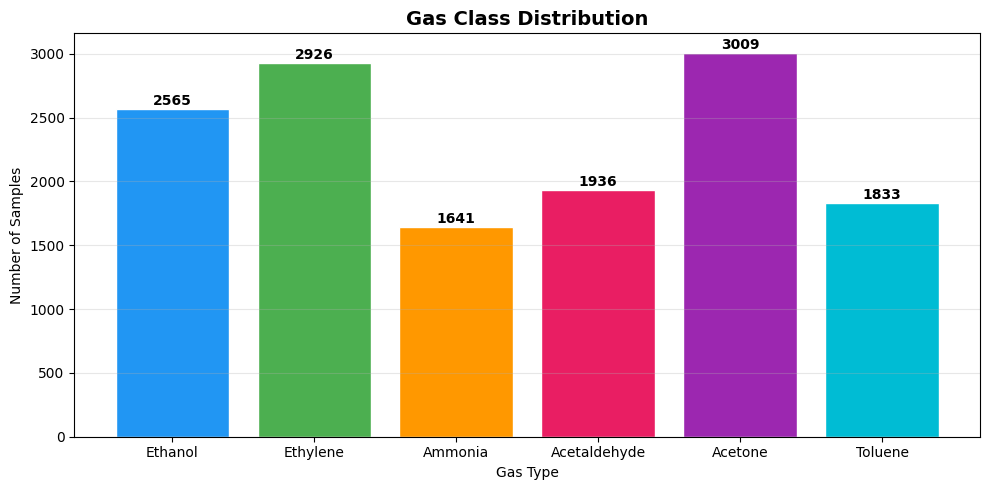

In [10]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================
counts = [np.sum(y_all == i) for i in range(1, 7)]
for gas_id, count in zip(range(1, 7), counts):
    print(f"Class {gas_id} {gas_names_dict[gas_id]}: {count} ({count/len(y_all)*100:.1f}%)")

colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#00BCD4"]

plt.figure(figsize=(10, 5))
bars = plt.bar(GAS_NAMES, counts, color=colors, edgecolor="white")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
              str(count), ha="center", fontweight="bold")
plt.title("Gas Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Gas Type")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================
print("\nFEATURE STATISTICS")
print("-" * 50)
desc = df_check.describe().T
print(desc[["mean", "std", "min", "max"]].head(10))


FEATURE STATISTICS
--------------------------------------------------
           mean           std           min            max
0  50435.066174  69844.785952 -16757.598600  670687.347700
1      6.638156     13.486391      0.088287    1339.879283
2     12.936688     17.610061      0.000100     167.079751
3     18.743953     24.899450      0.000100     226.619457
4     26.890695     38.107685      0.000100     993.605306
5     -9.158655     12.729206   -131.332873      -0.006941
6    -14.402383     21.304606   -227.627758      22.201589
7    -59.927598    131.017675  -1664.735576     115.273147
8  57340.104585  64045.265134 -16119.460900  502202.812500
9      6.648033     15.585780      0.185164    1672.363221


In [12]:
# ============================================================
# OUTLIER DETECTION USING IQR
# ============================================================
Q1 = df_check.quantile(0.25)
Q3 = df_check.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = ((df_check < lower_bound) | (df_check > upper_bound))
samples_with_outliers = outlier_mask.any(axis=1).sum()

print("\nOUTLIER DETECTION (IQR method)")
print("-" * 40)
print(f"Samples with at least one outlier feature: "
      f"{samples_with_outliers} / {len(df_check)} "
      f"({samples_with_outliers/len(df_check)*100:.1f}%)")
print(f"Average outlier features per sample      : {outlier_mask.sum(axis=1).mean():.2f}")


OUTLIER DETECTION (IQR method)
----------------------------------------
Samples with at least one outlier feature: 4887 / 13910 (35.1%)
Average outlier features per sample      : 5.78


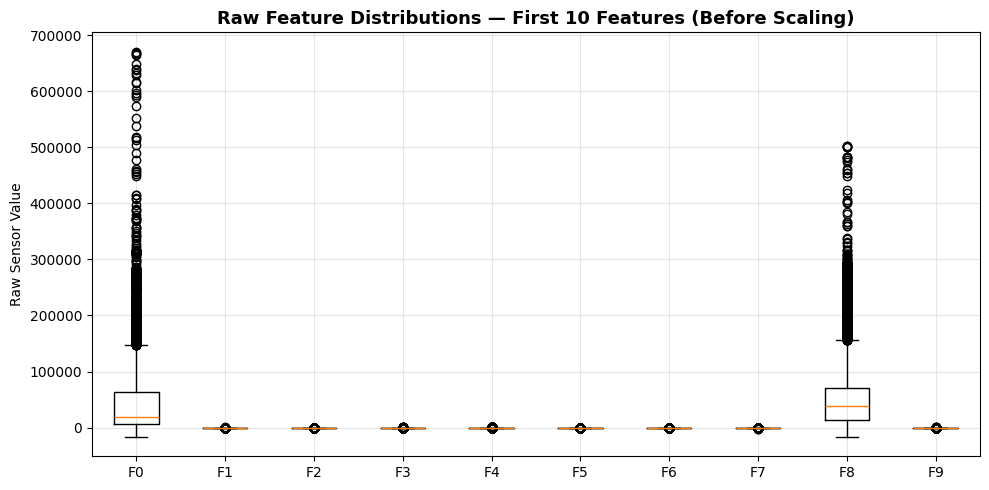

In [13]:
# ============================================================
# RAW FEATURE BOXPLOT
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
sample_features = df_check.iloc[:, :10]
ax.boxplot([sample_features[c] for c in sample_features.columns],
           tick_labels=[f'F{i}' for i in range(10)])
ax.set_title('Raw Feature Distributions — First 10 Features (Before Scaling)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Raw Sensor Value')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('preprocessing_boxplot_raw.png', dpi=150, bbox_inches='tight')
plt.show()

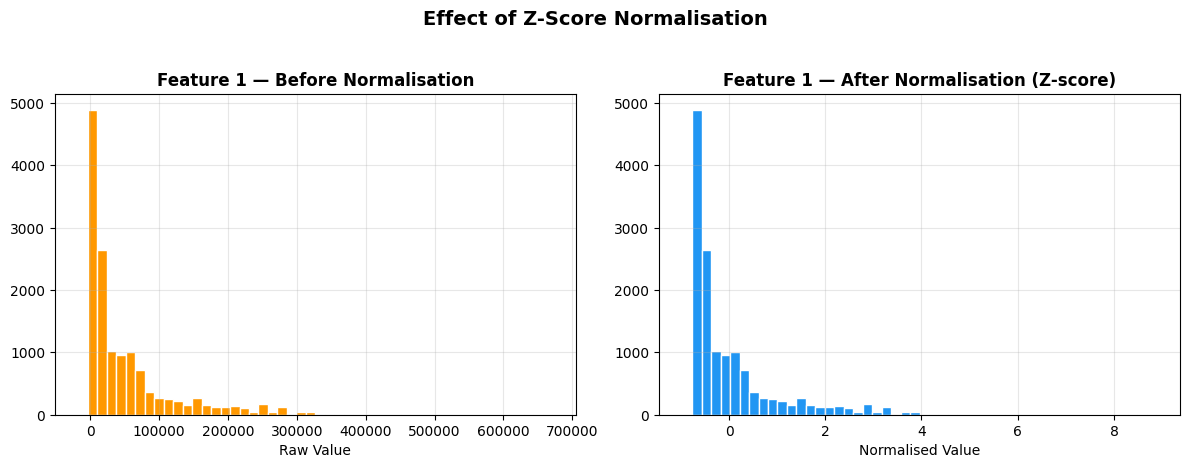

In [14]:
# ============================================================
# NORMALISATION VISUALISATION — EDA ONLY, ALL 10 BATCHES
# ============================================================.
scaler = StandardScaler()
X_normalised = scaler.fit_transform(X_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.hist(X_all[:, 0], bins=50, color='#FF9800', edgecolor='white')
ax1.set_title('Feature 1 — Before Normalisation', fontweight='bold')
ax1.set_xlabel('Raw Value')
ax1.grid(alpha=0.3)

ax2.hist(X_normalised[:, 0], bins=50, color='#2196F3', edgecolor='white')
ax2.set_title('Feature 1 — After Normalisation (Z-score)', fontweight='bold')
ax2.set_xlabel('Normalised Value')
ax2.grid(alpha=0.3)

plt.suptitle('Effect of Z-Score Normalisation', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('preprocessing_normalisation_hist.png', dpi=150, bbox_inches='tight')
plt.show()

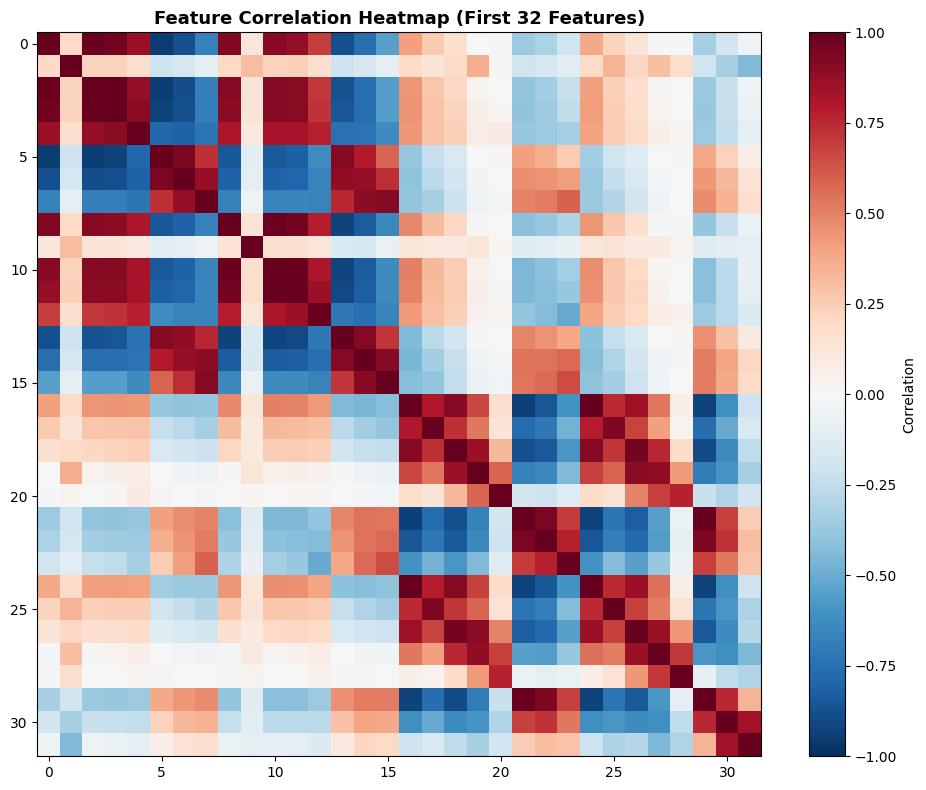

In [15]:
# ============================================================
# CORRELATION HEATMAP (first 32 features)
# ============================================================
corr = df_check.iloc[:, :32].corr()
fig, ax = plt.subplots(
    figsize=(10, 8)
)
im = ax.imshow(
    corr,
    cmap='RdBu_r',
    vmin=-1,
    vmax=1
)
plt.colorbar(
    im,
    ax=ax,
    label='Correlation'
)
ax.set_title(
    'Feature Correlation Heatmap (First 32 Features)',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    'preprocessing_correlation_heatmap.png',
    dpi=200,
    bbox_inches='tight'
)
plt.show()

In [16]:
# ============================================================
# FEATURE STRUCTURE
# ============================================================
print("\nFEATURE STRUCTURE")
print("-" * 50)
print("128 features = 16 sensors x 8 descriptors")

feature_names = [
    "Steady-state value", "Maximum response", "Minimum value", "Mean response",
    "Response variance", "Rising slope", "Area under curve", "Recovery slope"
]
for i, name in enumerate(feature_names):
    print(f"Descriptor {i+1}: {name}")

print("\nImportant:")
print("The 8 values are sensor descriptors, not temporal timesteps.")


FEATURE STRUCTURE
--------------------------------------------------
128 features = 16 sensors x 8 descriptors
Descriptor 1: Steady-state value
Descriptor 2: Maximum response
Descriptor 3: Minimum value
Descriptor 4: Mean response
Descriptor 5: Response variance
Descriptor 6: Rising slope
Descriptor 7: Area under curve
Descriptor 8: Recovery slope

Important:
The 8 values are sensor descriptors, not temporal timesteps.


In [17]:
# ============================================================
# SENSOR-DESCRIPTOR REPRESENTATION  (fit on all 10 batches)
# ============================================================
X_sensor = X_normalised.reshape(-1, 16, 8)
print("Sensor-descriptor shape:", X_sensor.shape)
print("Meaning: (samples, 16 sensors, 8 descriptors)")

Sensor-descriptor shape: (13910, 16, 8)
Meaning: (samples, 16 sensors, 8 descriptors)


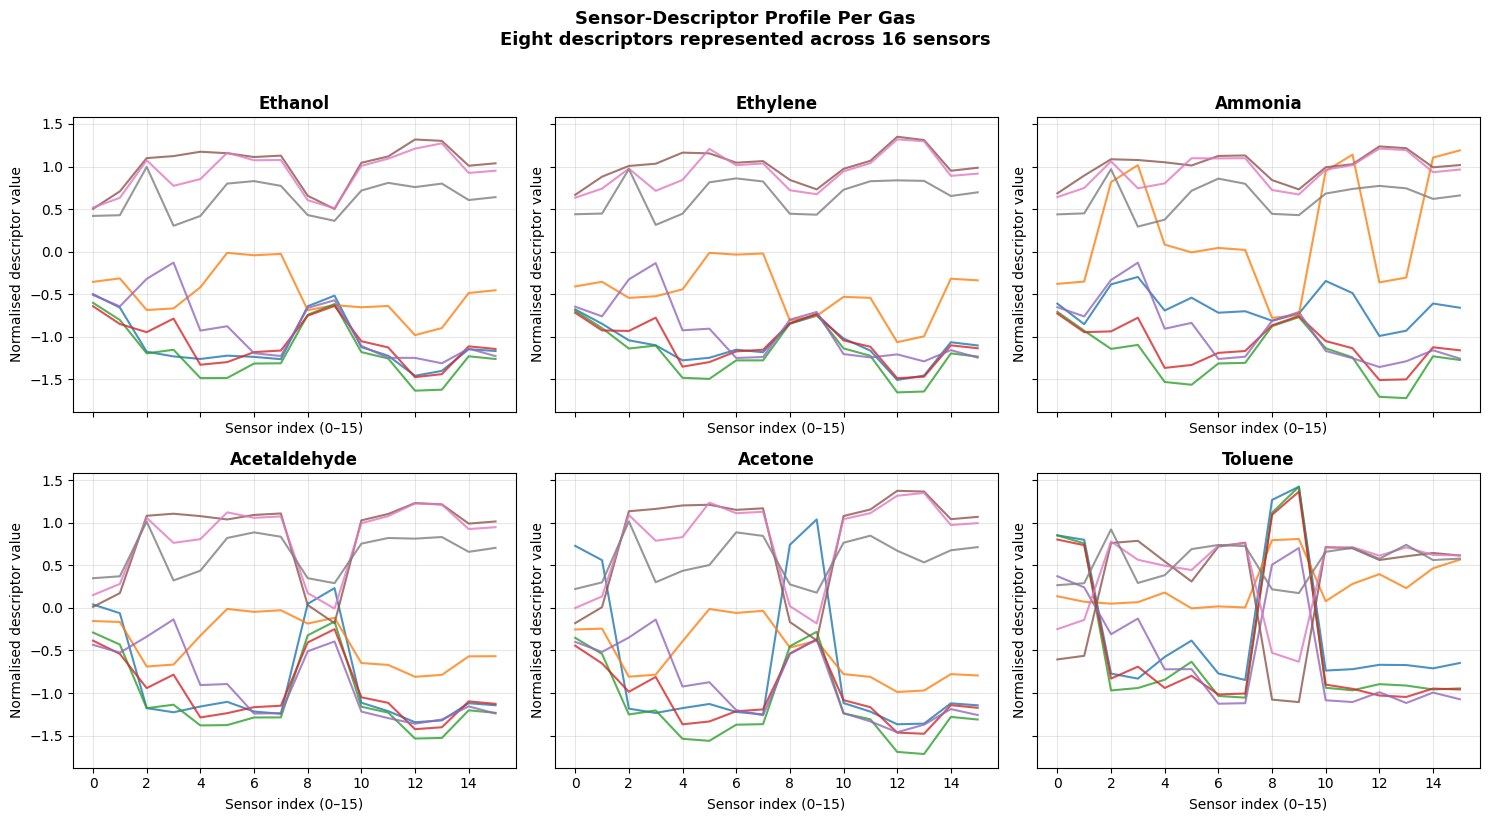

In [18]:
# ============================================================
# SENSOR-DESCRIPTOR PROFILE PER GAS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for i, gas_id in enumerate(range(1, 7)):
    idx = np.where(y_all == gas_id)[0][0]
    sample_sensor_data = X_sensor[idx]
    for descriptor in range(8):
        axes[i].plot(range(16), sample_sensor_data[:, descriptor], linewidth=1.5, alpha=0.8)
    axes[i].set_title(gas_names_dict[gas_id], fontweight='bold')
    axes[i].set_xlabel("Sensor index (0–15)")
    axes[i].set_ylabel("Normalised descriptor value")
    axes[i].grid(alpha=0.3)

plt.suptitle("Sensor-Descriptor Profile Per Gas\nEight descriptors represented across 16 sensors",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("sensor_descriptor_profile_per_gas.png", dpi=150, bbox_inches='tight')
plt.show()

X_sensor shape: (13910, 16, 8)
Interpretation: (samples, 16 sensors, 8 descriptors)
The sensor dimension is an ordered spatial/sensor index, not time.
Ethanol: sample index = 0, shape = (16, 8)
Ethylene: sample index = 84, shape = (16, 8)
Ammonia: sample index = 172, shape = (16, 8)
Acetaldehyde: sample index = 271, shape = (16, 8)
Acetone: sample index = 301, shape = (16, 8)
Toluene: sample index = 371, shape = (16, 8)


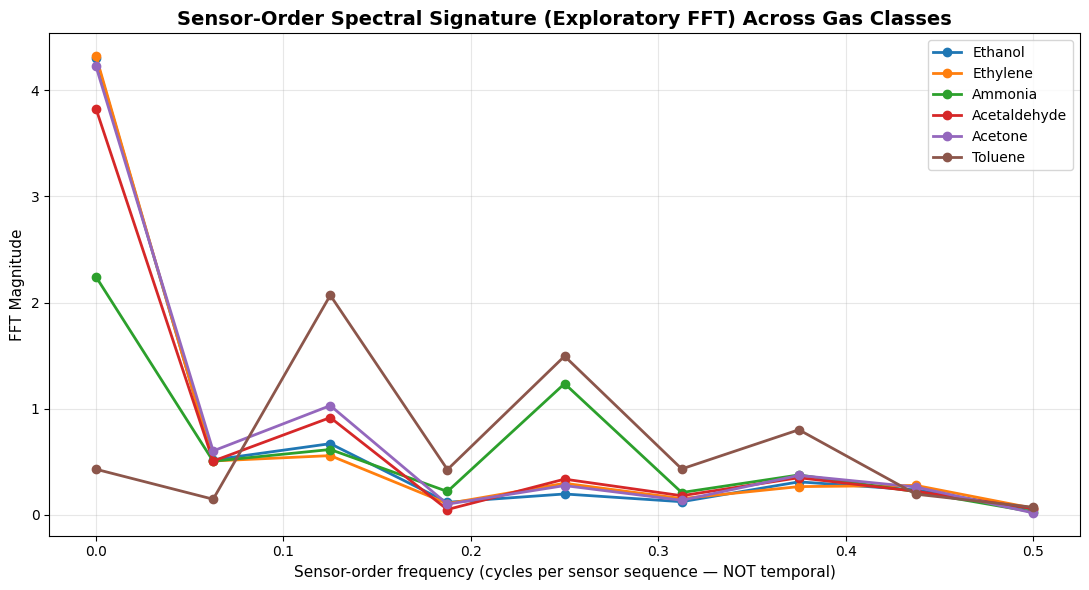


Exploratory FFT analysis completed for all six gas classes.
Interpretation: spectral patterns represent periodic structure across the ordered sensor dimension only. No temporal or chronological interpretation should be drawn from this analysis.

FFT feature matrix shape: (13910, 9)
FFT features saved to:
results/fft_features.npy


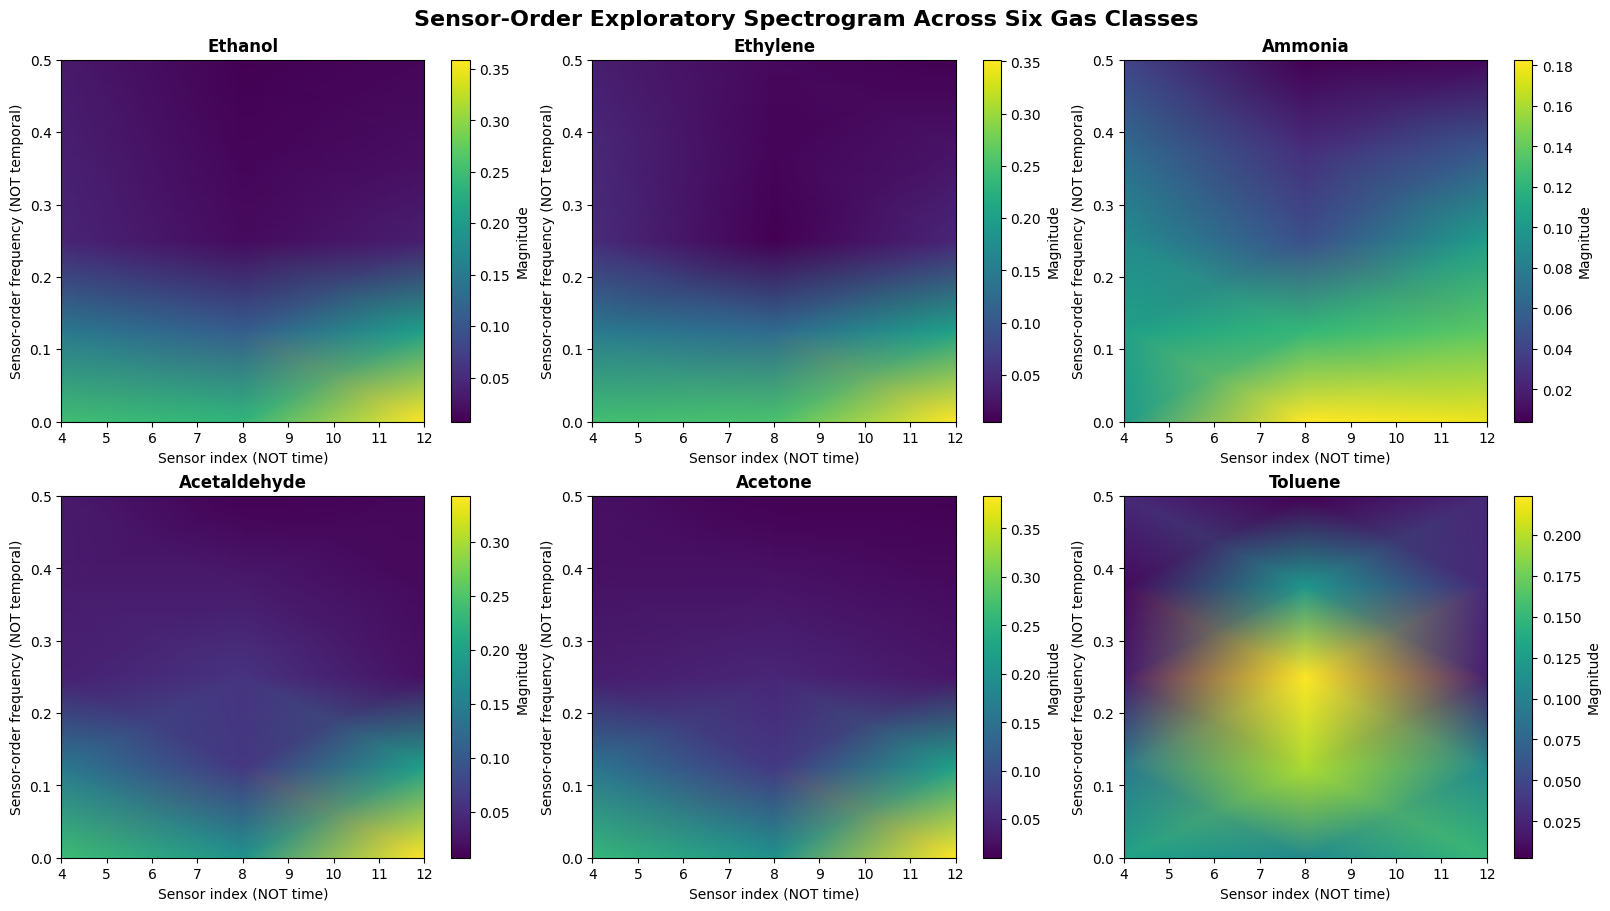


Sensor-order exploratory spectrogram generated for all six gas classes.
Important: the horizontal dimension represents sensor index only. This analysis carries no temporal or chronological interpretation.


In [19]:
# ============================================================
# SENSOR-ORDER EXPLORATORY SPECTRAL ANALYSIS — FFT + STFT
# All 6 Gas Classes
#
# CAUTION: The 16 values per descriptor are 16 SENSOR POSITIONS,
# not sequential time samples. FFT/STFT are applied here purely as
# an exploratory tool to look for periodic structure across the
# ordered sensor axis (e.g. repeating sensor-type groupings on the
# board). "Frequency" below means "cycles per sensor sequence,"
# NOT temporal frequency in Hz, and nothing in this cell should be
# read as evidence of chronological/time-series behaviour in the
# underlying descriptors.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import stft
import os

os.makedirs("results", exist_ok=True)

# ------------------------------------------------------------
# GAS NAMES
# ------------------------------------------------------------
GAS_NAME_MAP = {
    1: "Ethanol",
    2: "Ethylene",
    3: "Ammonia",
    4: "Acetaldehyde",
    5: "Acetone",
    6: "Toluene"
}

# ------------------------------------------------------------
# DATA STRUCTURE
# X_sensor = (samples, 16 sensors, 8 descriptors)
# IMPORTANT:
# The 16 positions represent an ORDERED SET OF SENSORS,
# not temporal timesteps. No chronological interpretation applies.
# ------------------------------------------------------------

print("X_sensor shape:", X_sensor.shape)
print("Interpretation: (samples, 16 sensors, 8 descriptors)")
print("The sensor dimension is an ordered spatial/sensor index, not time.")


# ============================================================
# SELECT ONE REPRESENTATIVE SAMPLE PER GAS
# ============================================================

representative_samples = {}

for gas_id, gas_name in GAS_NAME_MAP.items():

    indices = np.where(y_all == gas_id)[0]

    if len(indices) == 0:
        print(f"Warning: No samples found for {gas_name}")
        continue

    # Use the first available sample for reproducibility
    sample_index = indices[0]

    representative_samples[gas_id] = X_sensor[sample_index]

    print(
        f"{gas_name}: "
        f"sample index = {sample_index}, "
        f"shape = {X_sensor[sample_index].shape}"
    )
# ===========================================================
# SENSOR-ORDER SPECTRAL SIGNATURE — FFT (EXPLORATORY)
# ============================================================
# For each gas:
#   - Average the 8 descriptors at each of the 16 sensors
#   - Apply FFT across the ordered sensor dimension
#
# This is an exploratory transform over SENSOR ORDER, not a
# temporal-frequency analysis. It describes periodic structure
# across the ordered sensors only (e.g. layout/grouping effects),
# with no implication that the descriptors evolve over time.
# ============================================================

fft_signatures = {}
fft_frequency = None

for gas_id, gas_name in GAS_NAME_MAP.items():

    sample = representative_samples[gas_id]

    # sample shape = (16 sensors, 8 descriptors)
    # Average descriptors to obtain one value per sensor
    sensor_profile = sample.mean(axis=1)

    n_sensors = len(sensor_profile)

    # FFT across sensor-order dimension (NOT a time axis)
    fft_values = np.abs(rfft(sensor_profile))

    # "Frequency" here = cycles per sensor sequence, NOT Hz / temporal frequency
    frequencies = rfftfreq(n_sensors, d=1.0)

    fft_signatures[gas_id] = fft_values

    if fft_frequency is None:
        fft_frequency = frequencies


# ============================================================
# PLOT FFT SIGNATURES FOR ALL 6 GASES
# ============================================================

plt.figure(figsize=(11, 6))

for gas_id, gas_name in GAS_NAME_MAP.items():

    plt.plot(
        fft_frequency,
        fft_signatures[gas_id],
        marker="o",
        linewidth=2,
        label=gas_name
    )
plt.title(
    "Sensor-Order Spectral Signature (Exploratory FFT) Across Gas Classes",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel(
    "Sensor-order frequency (cycles per sensor sequence — NOT temporal)",
    fontsize=11
)
plt.ylabel(
    "FFT Magnitude",
    fontsize=11
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "results/sensor_order_fft_all_gases.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print(
    "\nExploratory FFT analysis completed for all six gas classes."
)
print(
    "Interpretation: spectral patterns represent periodic structure "
    "across the ordered sensor dimension only. No temporal or "
    "chronological interpretation should be drawn from this analysis."
)
# ===========================================================
# SAVE FFT FEATURES
# ============================================================
# Generate exploratory FFT features for every sample.
# These are sensor-order features, not time-series features.
# ============================================================

fft_features_all = []

for sample in X_sensor:

    # Average 8 descriptors for each sensor
    sensor_profile = sample.mean(axis=1)

    # FFT across 16 sensors (sensor-order axis, not time)
    fft_values = np.abs(rfft(sensor_profile))

    fft_features_all.append(fft_values)

fft_features_all = np.asarray(fft_features_all)

print(
    "\nFFT feature matrix shape:",
    fft_features_all.shape
)

np.save(
    "results/fft_features.npy",
    fft_features_all
)

print("FFT features saved to:")
print("results/fft_features.npy")
# ============================================================
# SENSOR-ORDER SPECTROGRAM — STFT (EXPLORATORY)
# ============================================================
# CAUTION: scipy.signal.stft is a "Short-Time Fourier Transform"
# function by name, but it is being repurposed here purely as a
# windowed-FFT tool over SENSOR ORDER. This is NOT a temporal
# spectrogram — there is no time axis anywhere in this analysis.
# The 16 positions correspond to sensors; the x-axis below is
# SENSOR INDEX. Results are exploratory only and should not be
# described as evidence of time-varying or chronological behaviour.
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
    constrained_layout=True
)

axes = axes.ravel()

for plot_index, (gas_id, gas_name) in enumerate(GAS_NAME_MAP.items()):

    sample = representative_samples[gas_id]

    # Average descriptors to create one sensor profile
    sensor_profile = sample.mean(axis=1)

    # Windowed FFT across the sensor-order dimension (fs=1.0 is a
    # unitless sample spacing over sensor index, not a real sample rate)
    frequencies, sensor_positions, Zxx = stft(
        sensor_profile,
        fs=1.0,
        nperseg=8,
        noverlap=4,
        boundary=None
    )

    magnitude = np.abs(Zxx)

    ax = axes[plot_index]

    im = ax.pcolormesh(
        sensor_positions,
        frequencies,
        magnitude,
        shading="gouraud"
    )

    ax.set_title(
        gas_name,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Sensor index (NOT time)",
        fontsize=10
    )

    ax.set_ylabel(
        "Sensor-order frequency (NOT temporal)",
        fontsize=10
    )

    ax.set_ylim(0, 0.5)

    fig.colorbar(
        im,
        ax=ax,
        label="Magnitude"
    )

fig.suptitle(
    "Sensor-Order Exploratory Spectrogram Across Six Gas Classes",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "results/sensor_order_spectrogram_all_gases.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\nSensor-order exploratory spectrogram generated for all six gas classes."
)

print(
    "Important: the horizontal dimension represents sensor index only. "
    "This analysis carries no temporal or chronological interpretation."
)

In [20]:
# ============================================================
# PCA  (fit on all 10 batches)
# ============================================================
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_normalised)

variance_explained = pca.explained_variance_ratio_ * 100
var1, var2 = variance_explained[0], variance_explained[1]

print(f"PC1 variance: {var1:.2f}%")
print(f"PC2 variance: {var2:.2f}%")
print(f"Combined variance: {var1 + var2:.2f}%")

PC1 variance: 53.52%
PC2 variance: 15.04%
Combined variance: 68.56%


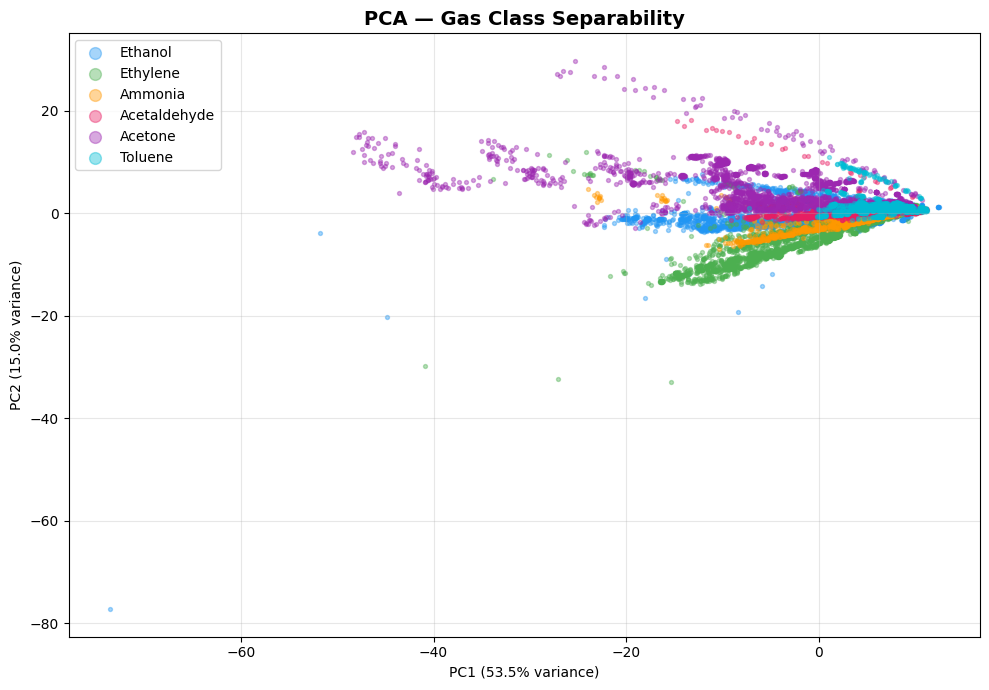

In [21]:
# ============================================================
# PCA GAS CLASS VISUALISATION
# ============================================================
plt.figure(figsize=(10, 7))
for i, gas_id in enumerate(range(1, 7)):
    mask = y_all == gas_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i],
                label=gas_names_dict[gas_id], alpha=0.4, s=8)

plt.xlabel(f"PC1 ({var1:.1f}% variance)")
plt.ylabel(f"PC2 ({var2:.1f}% variance)")
plt.title("PCA — Gas Class Separability", fontsize=14, fontweight="bold")
plt.legend(markerscale=3)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_visualisation.png", dpi=150, bbox_inches="tight")
plt.show()

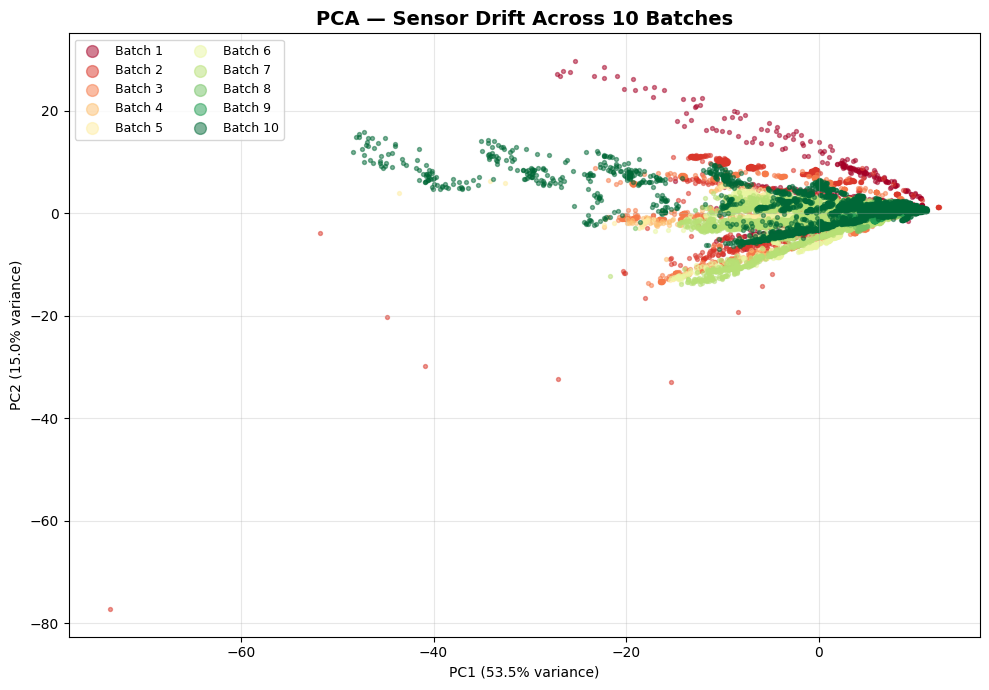

In [22]:
# ============================================================
# PCA BATCH DRIFT
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.RdYlGn
colors_batch = [cmap(i / 9) for i in range(10)]

for b in range(1, 11):
    mask = batch_ids == b
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors_batch[b-1]],
               label=f"Batch {b}", alpha=0.5, s=8)

ax.set_xlabel(f"PC1 ({var1:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var2:.1f}% variance)")
ax.set_title("PCA — Sensor Drift Across 10 Batches", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, markerscale=3, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_batch_drift.png", dpi=150, bbox_inches="tight")
plt.show()

SENSOR DRIFT OVER TIME — MEAN RESPONSE PER BATCH
--------------------------------------------------


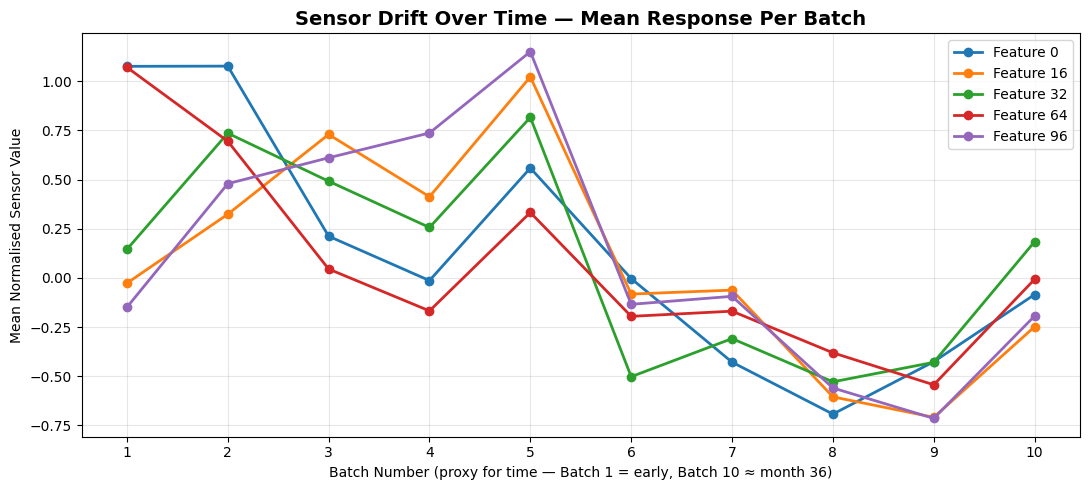

In [23]:
# ============================================================
# SENSOR DRIFT OVER TIME — MEAN RESPONSE PER BATCH
# ============================================================
print("SENSOR DRIFT OVER TIME — MEAN RESPONSE PER BATCH")
print("-" * 50)

feature_indices = [0, 16, 32, 64, 96]   # spread across the 128 raw columns
feature_labels = [f"Feature {i}" for i in feature_indices]

batch_feature_means = np.zeros((10, len(feature_indices)))
for b in range(1, 11):
    mask = batch_ids == b
    for j, feat_idx in enumerate(feature_indices):
        batch_feature_means[b-1, j] = X_normalised[mask, feat_idx].mean()

fig, ax = plt.subplots(figsize=(11, 5))
for j, label in enumerate(feature_labels):
    ax.plot(range(1, 11), batch_feature_means[:, j], marker="o", linewidth=2, label=label)

ax.set_xlabel("Batch Number (proxy for time — Batch 1 = early, Batch 10 ≈ month 36)")
ax.set_ylabel("Mean Normalised Sensor Value")
ax.set_title("Sensor Drift Over Time — Mean Response Per Batch", fontsize=14, fontweight="bold")
ax.set_xticks(range(1, 11))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("sensor_drift_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

SENSOR 1 — DESCRIPTOR PROFILE BY GAS TYPE
--------------------------------------------------


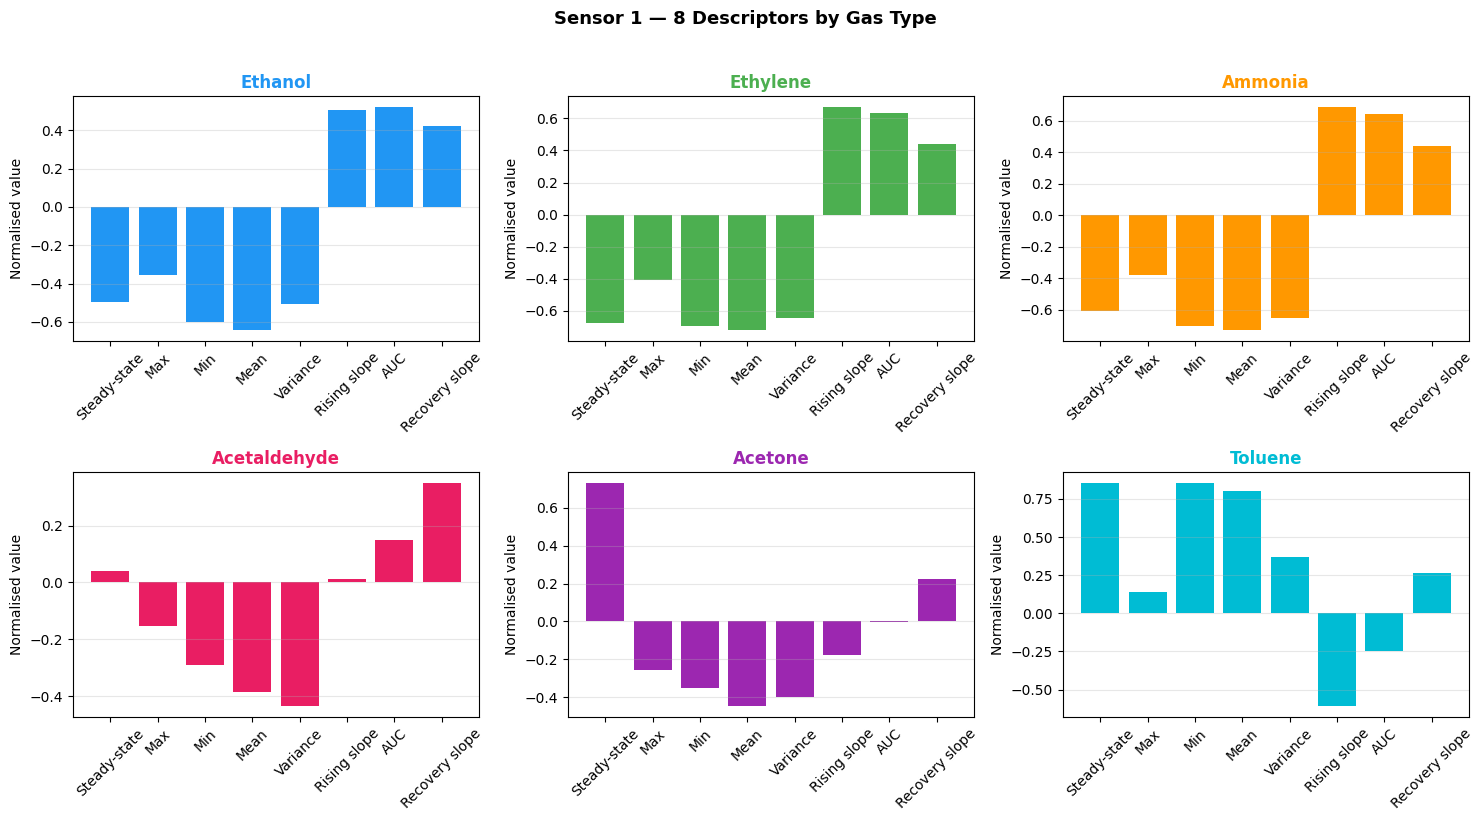

In [24]:
# ============================================================
# SENSOR1: DESCRIPTOR PROFILE BY GAS TYPE
# ============================================================
print("SENSOR 1 — DESCRIPTOR PROFILE BY GAS TYPE")
print("-" * 50)

descriptor_labels = ["Steady-state", "Max", "Min", "Mean",
                      "Variance", "Rising slope", "AUC", "Recovery slope"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, gas_id in enumerate(range(1, 7)):
    idx = np.where(y_all == gas_id)[0][0]
    sensor1_descriptors = X_sensor[idx, 0, :]   # sensor 0 (Sensor 1), all 8 descriptors

    axes[i].bar(descriptor_labels, sensor1_descriptors, color=colors[i])
    axes[i].set_title(gas_names_dict[gas_id], fontweight="bold", color=colors[i])
    axes[i].set_ylabel("Normalised value")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(alpha=0.3, axis="y")

plt.suptitle("Sensor 1 — 8 Descriptors by Gas Type",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("sensor1_descriptor_profile_by_gas.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# ============================================================
# EDA/VISUALIZATION SCALER
# ============================================================
# `scaler`, `X_normalised`, `X_sensor`, and `X_pca` above were fit on
# ALL 10 batches. Valid for visualization; NOT valid for training or
# drift evaluation (would leak late-batch statistics into preprocessing).
#
# Everything from here on uses a SEPARATE scaler (`model_scaler`) fit
# only on Batches 1-3.
print("EDA scaler/X_normalised/X_sensor/X_pca are for visualization only.")
print("Modeling pipeline below uses a fresh scaler fit on Batches 1-3 only.")

EDA scaler/X_normalised/X_sensor/X_pca are for visualization only.
Modeling pipeline below uses a fresh scaler fit on Batches 1-3 only.


In [26]:
# ============================================================
# ROBUSTNESS METRICS — applied identically to every model
# ============================================================
def evaluate_per_batch(y_true_by_batch, y_pred_by_batch, batch_numbers):
    per_batch_acc, per_batch_f1 = {}, {}
    for b in batch_numbers:
        yt, yp = y_true_by_batch[b], y_pred_by_batch[b]
        per_batch_acc[b] = accuracy_score(yt, yp) * 100
        per_batch_f1[b]  = f1_score(yt, yp, average="macro", zero_division=0) * 100

    late_batches = [b for b in batch_numbers if b >= 8]
    mean_late_acc  = np.mean([per_batch_acc[b] for b in late_batches])
    worst_late_acc = np.min([per_batch_acc[b] for b in late_batches])
    mean_late_f1   = np.mean([per_batch_f1[b] for b in late_batches])

    best_acc = max(per_batch_acc.values())
    acc_drop = best_acc - worst_late_acc

    y_true_all = np.concatenate([y_true_by_batch[b] for b in batch_numbers])
    y_pred_all = np.concatenate([y_pred_by_batch[b] for b in batch_numbers])
    balanced_acc_all = balanced_accuracy_score(y_true_all, y_pred_all) * 100

    return {
        "per_batch_accuracy": per_batch_acc,
        "per_batch_macro_f1": per_batch_f1,
        "mean_late_batch_accuracy": mean_late_acc,
        "worst_late_batch_accuracy": worst_late_acc,
        "mean_late_batch_macro_f1": mean_late_f1,
        "balanced_accuracy_overall": balanced_acc_all,
        "accuracy_drop": acc_drop,
    }

def print_robustness(name, metrics):
    print(f"\n--- Robustness summary: {name} ---")
    print(f"  Mean late-batch accuracy (8-10): {metrics['mean_late_batch_accuracy']:.2f}%")
    print(f"  Worst late-batch accuracy       : {metrics['worst_late_batch_accuracy']:.2f}%")
    print(f"  Mean late-batch macro-F1        : {metrics['mean_late_batch_macro_f1']:.2f}%")
    print(f"  Balanced accuracy (overall)     : {metrics['balanced_accuracy_overall']:.2f}%")
    print(f"  Accuracy drop (best - worst)    : {metrics['accuracy_drop']:.2f} pts")

def plot_confusion(y_true, y_pred, title, save_path, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(6)); ax.set_yticks(range(6))
    ax.set_xticklabels(GAS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(GAS_NAMES)
    for i in range(6):
        for j in range(6):
            color = "white" if cm[i, j] > cm.max()/2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontweight="bold")
    plt.colorbar(im, ax=ax)
    ax.set_xlabel("Predicted Gas"); ax.set_ylabel("Actual Gas")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def plot_degradation_curve(batch_metrics, batches, title, save_path, color):
    accs_curve = [batch_metrics["per_batch_accuracy"][b] for b in batches]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(batches, accs_curve, "o-", linewidth=2.5, markersize=9, color=color)
    ax.axhline(y=batch_metrics["mean_late_batch_accuracy"], color="red", linestyle="--", alpha=0.6,
               label=f"Mean late-batch acc ({batch_metrics['mean_late_batch_accuracy']:.1f}%)")
    ax.set_xlabel("Batch Number (trained on Batches 1-3 only)")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(title)
    ax.set_xticks(batches)
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [27]:
# ============================================================
# SCALING
# ============================================================
def fit_scaler_on_indices(X, fit_mask):
    scaler = StandardScaler()
    scaler.fit(X[fit_mask])
    return scaler

def apply_scaler(X, scaler):
    return scaler.transform(X)

In [28]:
# ============================================================
# SVM — MIXED-SPLIT TRAINING
# ============================================================
set_seed(SEED)

train_idx, test_idx = train_test_split(
    np.arange(len(y_all)), test_size=0.30, random_state=SEED, stratify=y_all
)
train_mask = np.zeros(len(y_all), dtype=bool); train_mask[train_idx] = True
test_mask  = ~train_mask

scaler_mixed = fit_scaler_on_indices(X_all, train_mask)
X_train = apply_scaler(X_all[train_mask], scaler_mixed)
X_test  = apply_scaler(X_all[test_mask],  scaler_mixed)
y_train, y_test = y_all[train_mask], y_all[test_mask]

param_grid = {"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.1, 1], "kernel": ["rbf"]}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

print("Running GridSearchCV for SVM (may take a few minutes)...")
grid = GridSearchCV(SVC(random_state=SEED), param_grid, cv=cv,
                     scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"\nBest params: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_*100:.2f}%")

svm_mixed = grid.best_estimator_
y_pred_svm_mixed = svm_mixed.predict(X_test)
svm_mixed_acc = accuracy_score(y_test, y_pred_svm_mixed) * 100

joblib.dump(svm_mixed,    "models/svm_mixed_model.pkl")
joblib.dump(scaler_mixed, "models/scaler_mixed.pkl")
print(f"\nSVM mixed-split test accuracy: {svm_mixed_acc:.2f}%")

Running GridSearchCV for SVM (may take a few minutes)...
Fitting 10 folds for each of 16 candidates, totalling 160 fits

Best params: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 99.36%

SVM mixed-split test accuracy: 99.35%


SVM — MIXED-SPLIT EVALUATION

Best hyperparameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Test accuracy: 99.35%

Classification report:
              precision    recall  f1-score   support

     Ethanol       1.00      0.99      1.00       769
    Ethylene       1.00      0.99      0.99       878
     Ammonia       0.99      0.98      0.99       492
Acetaldehyde       1.00      0.99      1.00       581
     Acetone       0.98      1.00      0.99       903
     Toluene       1.00      1.00      1.00       550

    accuracy                           0.99      4173
   macro avg       0.99      0.99      0.99      4173
weighted avg       0.99      0.99      0.99      4173



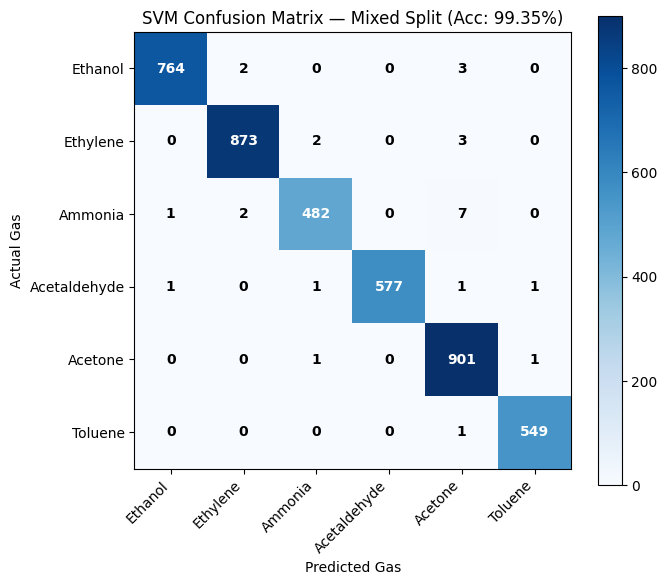

In [29]:
# ============================================================
# SVM EVALUATION — MIXED-SPLIT
# ============================================================
print("="*60)
print("SVM — MIXED-SPLIT EVALUATION")
print("="*60)
print(f"\nBest hyperparameters: {grid.best_params_}")
print(f"Test accuracy: {svm_mixed_acc:.2f}%")
print("\nClassification report:")
print(classification_report(y_test, y_pred_svm_mixed, target_names=GAS_NAMES))

plot_confusion(y_test, y_pred_svm_mixed,
               f"SVM Confusion Matrix — Mixed Split (Acc: {svm_mixed_acc:.2f}%)",
               "results/svm_mixed_confusion_matrix.png", cmap="Blues")

In [30]:
# ============================================================
# SVM — DRIFT TRAINING
# ============================================================
set_seed(SEED)

TRAIN_BATCHES = [1, 2, 3]
ALL_TEST_BATCHES = list(range(4, 11))
FINAL_TEST_BATCHES = [8, 9, 10]

train_mask_drift = np.isin(batch_ids, TRAIN_BATCHES)
scaler_drift = fit_scaler_on_indices(X_all, train_mask_drift)   # fit on B1-3 ONLY

X_train_drift = apply_scaler(X_all[train_mask_drift], scaler_drift)
y_train_drift = y_all[train_mask_drift]

# Batches 1-3 training data.
print("Running GridSearchCV for drift SVM (Batches 1-3 only)...")
cv_drift = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
grid_drift = GridSearchCV(SVC(random_state=SEED), param_grid, cv=cv_drift,
                           scoring="accuracy", n_jobs=-1, verbose=1)
grid_drift.fit(X_train_drift, y_train_drift)

print(f"\nBest params (drift, B1-3 only): {grid_drift.best_params_}")
print(f"Best CV accuracy (drift, B1-3 only): {grid_drift.best_score_*100:.2f}%")

svm_drift = grid_drift.best_estimator_

y_true_by_batch, y_pred_by_batch = {}, {}
print("SVM drift experiment — per-batch accuracy:")
for b in ALL_TEST_BATCHES:
    mask = batch_ids == b
    X_b = apply_scaler(X_all[mask], scaler_drift)
    y_b = y_all[mask]
    y_pred_b = svm_drift.predict(X_b)
    y_true_by_batch[b] = y_b
    y_pred_by_batch[b] = y_pred_b
    print(f"  Batch {b:2d}: {accuracy_score(y_b, y_pred_b)*100:.2f}%")

svm_drift_metrics = evaluate_per_batch(y_true_by_batch, y_pred_by_batch, ALL_TEST_BATCHES)

joblib.dump(svm_drift,    "models/svm_drift_model.pkl")
joblib.dump(scaler_drift, "models/scaler_drift_b1to3.pkl")
with open("results/svm_drift_metrics.json", "w") as f:
    json.dump(svm_drift_metrics, f, default=str, indent=2)

Running GridSearchCV for drift SVM (Batches 1-3 only)...
Fitting 10 folds for each of 16 candidates, totalling 160 fits

Best params (drift, B1-3 only): {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy (drift, B1-3 only): 99.33%
SVM drift experiment — per-batch accuracy:
  Batch  4: 88.20%
  Batch  5: 94.92%
  Batch  6: 71.04%
  Batch  7: 69.25%
  Batch  8: 78.23%
  Batch  9: 64.47%
  Batch 10: 40.83%


SVM — DRIFT EXPERIMENT EVALUATION

--- Robustness summary: SVM (drift) ---
  Mean late-batch accuracy (8-10): 61.18%
  Worst late-batch accuracy       : 40.83%
  Mean late-batch macro-F1        : 51.42%
  Balanced accuracy (overall)     : 60.64%
  Accuracy drop (best - worst)    : 54.09 pts

Per-batch accuracy and macro-F1:
  Batch  4: acc=88.20%  macro-F1=91.15%
  Batch  5: acc=94.92%  macro-F1=94.64%
  Batch  6: acc=71.04%  macro-F1=63.51%
  Batch  7: acc=69.25%  macro-F1=65.64%
  Batch  8: acc=78.23%  macro-F1=58.35%
  Batch  9: acc=64.47%  macro-F1=55.65%
  Batch 10: acc=40.83%  macro-F1=40.25%

Classification report — combined Batches [8, 9, 10]:
              precision    recall  f1-score   support

     Ethanol       0.22      0.86      0.36       691
    Ethylene       0.86      0.39      0.54       685
     Ammonia       0.99      0.74      0.85       740
Acetaldehyde       0.43      0.23      0.30       708
     Acetone       0.93      0.52      0.67       821
     Toluene   

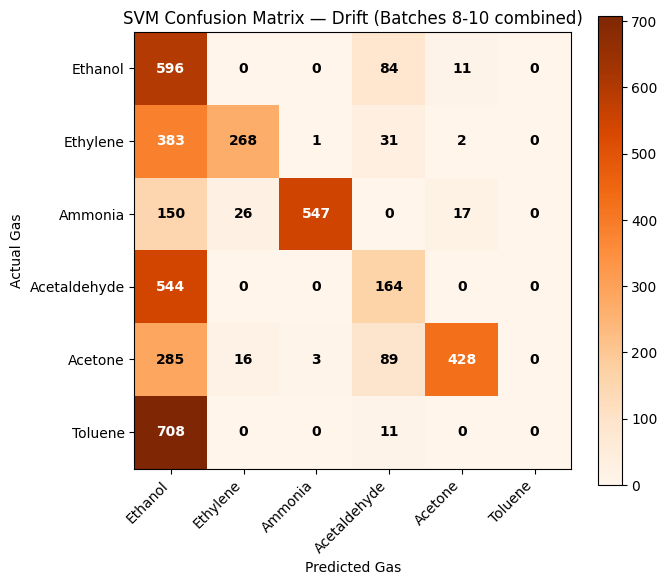

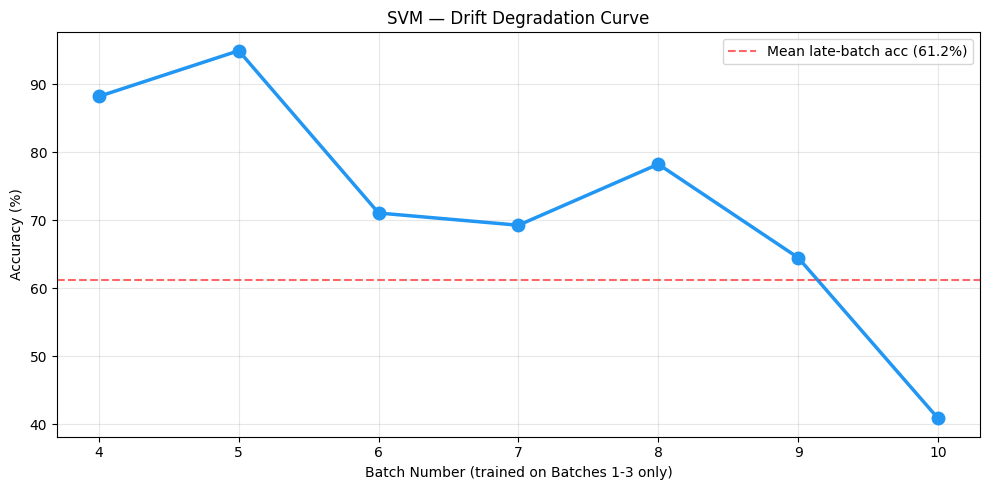

In [31]:
# ============================================================
# SVM EVALUATION — DRIFT EXPERIMENT
# ============================================================
print("="*60)
print("SVM — DRIFT EXPERIMENT EVALUATION")
print("="*60)
print_robustness("SVM (drift)", svm_drift_metrics)

print("\nPer-batch accuracy and macro-F1:")
for b in ALL_TEST_BATCHES:
    print(f"  Batch {b:2d}: acc={svm_drift_metrics['per_batch_accuracy'][b]:.2f}%  "
          f"macro-F1={svm_drift_metrics['per_batch_macro_f1'][b]:.2f}%")

y_true_final = np.concatenate([y_true_by_batch[b] for b in FINAL_TEST_BATCHES])
y_pred_final = np.concatenate([y_pred_by_batch[b] for b in FINAL_TEST_BATCHES])
print(f"\nClassification report — combined Batches {FINAL_TEST_BATCHES}:")
print(classification_report(y_true_final, y_pred_final, target_names=GAS_NAMES, zero_division=0))

plot_confusion(y_true_final, y_pred_final,
               "SVM Confusion Matrix — Drift (Batches 8-10 combined)",
               "results/svm_drift_confusion_matrix.png", cmap="Oranges")

plot_degradation_curve(svm_drift_metrics, ALL_TEST_BATCHES,
                        "SVM — Drift Degradation Curve",
                        "results/svm_drift_degradation_curve.png", color="#2196F3")

In [32]:
# ============================================================
# LSTM & Transformer model definitions
# ============================================================
class GasLSTM(nn.Module):
    """
    Treats the 16 sensors as a fixed-order sequence and their 8
    descriptors as the per-step feature vector. This is a structural
    ordering, NOT a temporal signal.
    """
    def __init__(self, input_size=8, hidden_size=64, num_layers=2, n_classes=6, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                             batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(self.dropout(last))


class GasTransformer(nn.Module):
    """
    Same sensor-order structure as GasLSTM, processed with self-attention
    across the 16 sensors instead of a temporal position encoding.
    """
    def __init__(self, input_dim=8, d_model=128, nhead=8, num_layers=2,
                 seq_len=16, n_classes=6, dropout=0.3):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoding = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x = self.embedding(x) + self.pos_encoding
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.fc(self.dropout(x))

In [33]:
# ============================================================
# TRAINING LOOP — with epoch-level progress printing,
# validation-based early stopping, repeated runs for
# reproducibility (mean ± std), AND history tracking for
# train/val curve plots.
# ============================================================
def train_model(model_class, X_train, y_train, model_kwargs=None,
                 n_epochs=60, patience=8, batch_size=64, lr=1e-3, seed=SEED,
                 verbose=True, print_every=5):
    set_seed(seed)
    model_kwargs = model_kwargs or {}

    n = len(y_train)
    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    val_size = int(0.15 * n)
    val_idx, tr_idx = idx[:val_size], idx[val_size:]

    X_tr_t = torch.FloatTensor(X_train[tr_idx]).to(device)
    y_tr_t = torch.LongTensor(y_train[tr_idx] - 1).to(device)
    X_val_t = torch.FloatTensor(X_train[val_idx]).to(device)
    y_val_t = torch.LongTensor(y_train[val_idx] - 1).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)

    model = model_class(**model_kwargs).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    # NEW: history tracking for train/val curve plots (fix #9)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if verbose:
        print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9}")
        print("-" * 55)

    for epoch in range(n_epochs):
        model.train()
        epoch_loss, correct_train, total_train = 0, 0, 0
        for xb, yb in loader:
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == yb).sum().item()
            total_train += yb.size(0)

        train_loss = epoch_loss / len(loader)
        train_acc = correct_train / total_train * 100

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t).item()
            val_acc = (torch.argmax(val_outputs, 1) == y_val_t).float().mean().item() * 100

        # NEW: record every epoch (not just the ones printed to console)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose and ((epoch + 1) % print_every == 0 or epoch == 0):
            print(f"{epoch+1:>6} {train_loss:>12.4f} {train_acc:>9.2f}% "
                  f"{val_loss:>10.4f} {val_acc:>8.2f}%")

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    model.load_state_dict(best_state)
    if verbose:
        print(f"Best val loss: {best_val_loss:.4f}\n")
    return model, history   # NEW: also return history


def repeated_train_eval(model_class, X_train, y_train, X_eval_dict, model_kwargs=None,
                         n_runs=3, base_seed=SEED, verbose=True):
    all_run_preds = {b: [] for b in X_eval_dict}
    trained_models = []
    all_histories = []   # NEW
    for run in range(n_runs):
        seed = base_seed + run
        if verbose:
            print(f"\n{'='*55}\nRUN {run+1}/{n_runs} (seed={seed})\n{'='*55}")
        model, history = train_model(model_class, X_train, y_train, model_kwargs, seed=seed, verbose=verbose)
        trained_models.append(model)
        all_histories.append(history)   # NEW
        model.eval()
        with torch.no_grad():
            for b, X_b in X_eval_dict.items():
                X_b_t = torch.FloatTensor(X_b).to(device)
                preds = torch.argmax(model(X_b_t), dim=1).cpu().numpy() + 1
                all_run_preds[b].append(preds)
    return all_run_preds, trained_models, all_histories   # NEW: also return histories


def plot_training_curves(history, title, save_path):
    """Plot train vs val loss and accuracy curves for one training run."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
    ax1.plot(epochs, history["val_loss"], label="Val Loss", linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs, history["train_acc"], label="Train Acc", linewidth=2)
    ax2.plot(epochs, history["val_acc"], label="Val Acc", linewidth=2)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title(f"{title} — Accuracy")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def to_sensor_seq(X_flat):
    return X_flat.reshape(-1, 16, 8)

>>> LSTM MIXED-SPLIT TRAINING <<<

RUN 1/3 (seed=42)
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       1.3458     42.18%     0.9189    60.00%
     5       0.2987     89.84%     0.3305    88.77%
    10       0.1875     93.92%     0.1612    94.52%
    15       0.1574     94.83%     0.1371    95.62%
    20       0.1215     96.05%     0.1210    95.55%
    25       0.1070     96.47%     0.1140    96.03%
    30       0.0846     97.14%     0.1166    96.64%
    35       0.0712     97.55%     0.1084    96.58%
    40       0.0631     97.76%     0.0711    98.01%
    45       0.0586     97.97%     0.0633    98.42%
    50       0.0555     98.19%     0.0721    97.74%
    55       0.0453     98.57%     0.0739    98.15%
    60       0.0471     98.26%     0.0593    98.49%
Best val loss: 0.0476


RUN 2/3 (seed=43)
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       

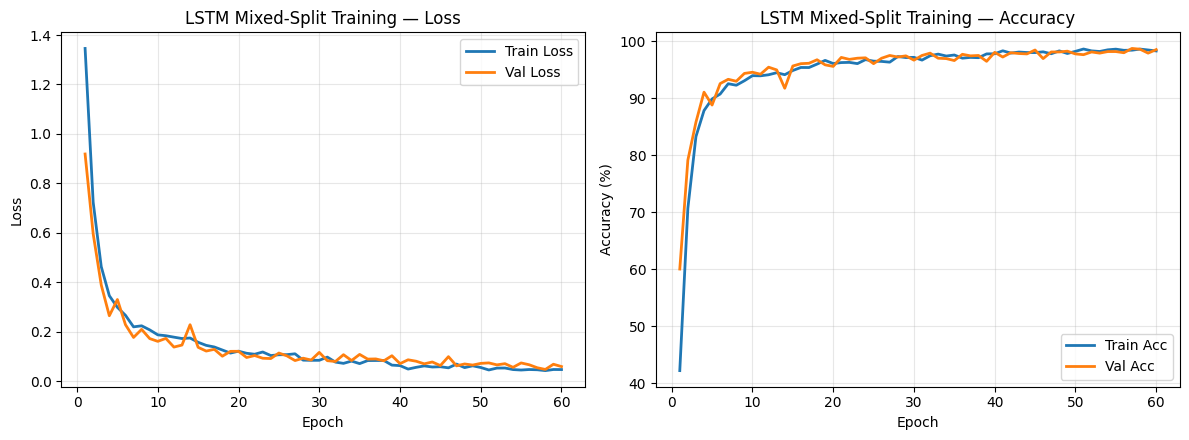


>>> LSTM DRIFT EXPERIMENT TRAINING <<<

RUN 1/3 (seed=42)
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       1.4569     47.31%     1.1234    54.18%
     5       0.2290     92.53%     0.1553    95.93%
    10       0.1176     96.88%     0.0999    97.35%
    15       0.0994     97.16%     0.2740    90.63%
    20       0.0607     98.49%     0.0570    98.37%
    25       0.0699     97.95%     0.0699    98.37%
Early stopping at epoch 28 (no improvement for 8 epochs)
Best val loss: 0.0570


RUN 2/3 (seed=43)
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       1.4688     42.96%     1.1055    54.38%
     5       0.3184     89.51%     0.3172    89.00%
    10       0.1135     96.95%     0.1762    96.33%
    15       0.0798     97.88%     0.1347    97.15%
    20       0.0637     98.38%     0.1611    95.52%
    25       0.0512     98.60%     0.1419    97.15%
  

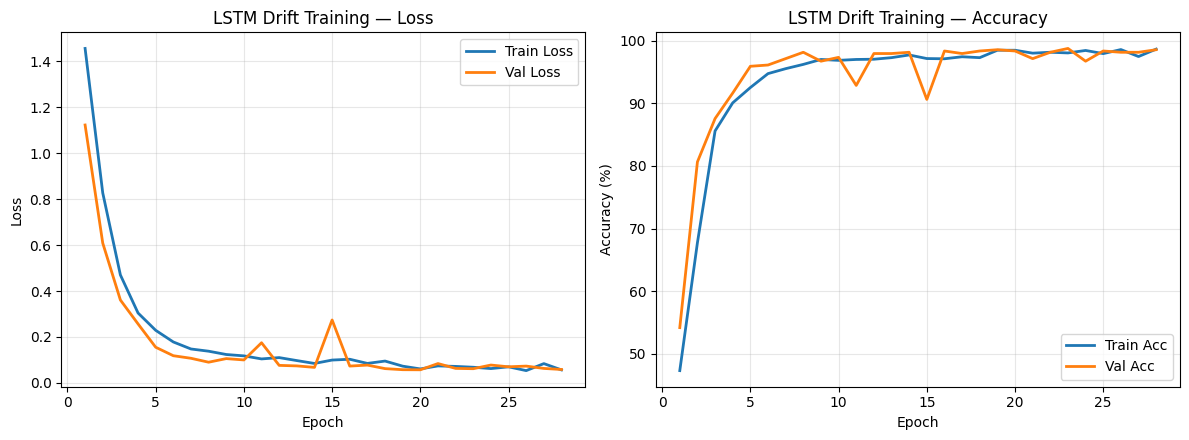

In [34]:
# ============================================================
# LSTM — TRAINING, both experiments, 3 repeated runs
# ============================================================

set_seed(SEED)

# ------------------------------------------------------------
# MIXED-SPLIT EXPERIMENT
# ------------------------------------------------------------
X_train_lstm_mixed = to_sensor_seq(
    apply_scaler(X_all[train_mask], scaler_mixed)
)

X_test_lstm_mixed = to_sensor_seq(
    apply_scaler(X_all[test_mask], scaler_mixed)
)

y_train_mixed = y_all[train_mask]
y_test_mixed = y_all[test_mask]

print(">>> LSTM MIXED-SPLIT TRAINING <<<")

preds_mixed, lstm_models_mixed, lstm_histories_mixed = repeated_train_eval(
    GasLSTM,
    X_train_lstm_mixed,
    y_train_mixed,
    {0: X_test_lstm_mixed},
    n_runs=3
)

accs = [
    accuracy_score(y_test_mixed, p) * 100
    for p in preds_mixed[0]
]

print(
    f"\nLSTM mixed-split accuracy over 3 runs: "
    f"{np.mean(accs):.2f}% ± {np.std(accs):.2f}%"
)

REPORT_RUN_LSTM_MIXED = 0

os.makedirs("models", exist_ok=True)

torch.save(
    lstm_models_mixed[REPORT_RUN_LSTM_MIXED].state_dict(),
    "models/lstm_mixed_model.pth"
)

plot_training_curves(
    lstm_histories_mixed[REPORT_RUN_LSTM_MIXED],
    "LSTM Mixed-Split Training",
    "results/lstm_mixed_training_curves.png"
)
# ============================================================
# LSTM — DRIFT EXPERIMENT
# Training uses Batches 1–3 only
# ============================================================

set_seed(SEED)

X_train_lstm_drift = to_sensor_seq(X_train_drift)
y_train_lstm_drift = y_train_drift

X_eval_dict_lstm = {
    b: to_sensor_seq(
        apply_scaler(
            X_all[batch_ids == b],
            scaler_drift
        )
    )
    for b in ALL_TEST_BATCHES
}

print("\n>>> LSTM DRIFT EXPERIMENT TRAINING <<<")

preds_drift, lstm_models_drift, lstm_histories_drift = repeated_train_eval(
    GasLSTM,
    X_train_lstm_drift,
    y_train_lstm_drift,
    X_eval_dict_lstm,
    n_runs=3
)
# ------------------------------------------------------------
# EVALUATE EACH DRIFT RUN
# ------------------------------------------------------------
y_true_by_batch_lstm = {
    b: y_all[batch_ids == b]
    for b in ALL_TEST_BATCHES
}
run_metrics_lstm = []

for r in range(3):

    y_pred_r = {
        b: preds_drift[b][r]
        for b in ALL_TEST_BATCHES
    }

    m = evaluate_per_batch(
        y_true_by_batch_lstm,
        y_pred_r,
        ALL_TEST_BATCHES
    )

    run_metrics_lstm.append(m)
# ------------------------------------------------------------
# MEAN / SD OF LATE-BATCH PERFORMANCE ACROSS 3 RUNS
# ------------------------------------------------------------

mean_late_accs_lstm = [
    m["mean_late_batch_accuracy"]
    for m in run_metrics_lstm
]
# ------------------------------------------------------------
# PREDEFINED REPORTING RUN
# Run 0 is selected in advance.
# It is NOT selected using held-out test performance.
# ------------------------------------------------------------

REPORT_RUN_LSTM = 0

y_pred_by_batch_lstm = {
    b: preds_drift[b][REPORT_RUN_LSTM]
    for b in ALL_TEST_BATCHES
}

lstm_drift_metrics = run_metrics_lstm[REPORT_RUN_LSTM]

lstm_drift_metrics[
    "mean_late_batch_acc_across_runs"
] = float(
    np.mean(mean_late_accs_lstm)
)

lstm_drift_metrics[
    "std_late_batch_acc_across_runs"
] = float(
    np.std(mean_late_accs_lstm)
)
# ------------------------------------------------------------
# SAVE DRIFT MODEL AND METRICS
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)

torch.save(
    lstm_models_drift[REPORT_RUN_LSTM].state_dict(),
    "models/lstm_drift_model.pth"
)

with open(
    "results/lstm_drift_metrics.json",
    "w"
) as f:

    json.dump(
        lstm_drift_metrics,
        f,
        default=str,
        indent=2
    )
# ------------------------------------------------------------
# REPORT DRIFT PERFORMANCE
# ------------------------------------------------------------

print(
    f"\nLSTM drift — mean late-batch acc over 3 runs: "
    f"{np.mean(mean_late_accs_lstm):.2f}% ± "
    f"{np.std(mean_late_accs_lstm):.2f}%"
)
# ------------------------------------------------------------
# SAVE TRAINING CURVE FOR PREDEFINED DRIFT RUN
# ------------------------------------------------------------

plot_training_curves(
    lstm_histories_drift[REPORT_RUN_LSTM],
    "LSTM Drift Training",
    "results/lstm_drift_training_curves.png"
)

LSTM — MIXED-SPLIT EVALUATION
LSTM mixed-split accuracy (predefined Run 1): 98.80%
LSTM mixed-split accuracy over 3 runs: 98.67% ± 0.10%

Classification report (predefined reporting run):
              precision    recall  f1-score   support

     Ethanol       0.99      0.99      0.99       769
    Ethylene       0.98      0.99      0.98       878
     Ammonia       0.99      0.97      0.98       492
Acetaldehyde       0.98      0.99      0.99       581
     Acetone       0.99      1.00      0.99       903
     Toluene       1.00      0.98      0.99       550

    accuracy                           0.99      4173
   macro avg       0.99      0.99      0.99      4173
weighted avg       0.99      0.99      0.99      4173



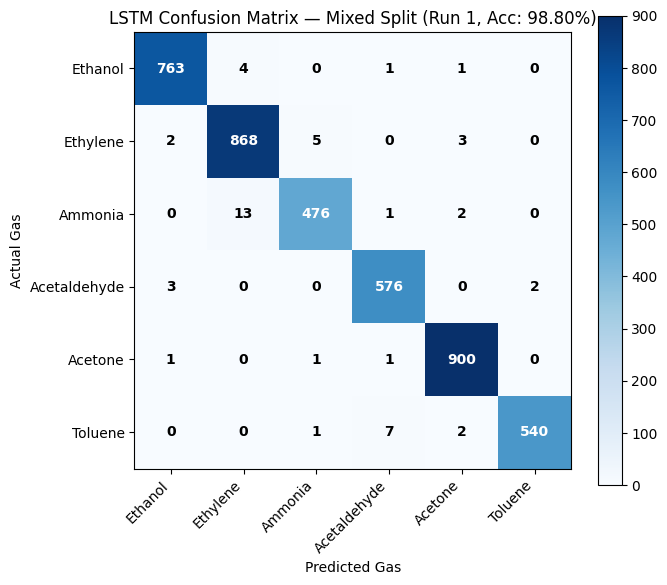


LSTM — DRIFT EXPERIMENT EVALUATION

--- Robustness summary: LSTM (drift) ---
  Mean late-batch accuracy (8-10): 43.88%
  Worst late-batch accuracy       : 40.21%
  Mean late-batch macro-F1        : 38.53%
  Balanced accuracy (overall)     : 63.07%
  Accuracy drop (best - worst)    : 57.25 pts

Stability across 3 runs (mean late-batch acc): 42.39% ± 1.36%

Per-batch accuracy and macro-F1:
  Batch  4: acc=72.67%  macro-F1=75.62%
  Batch  5: acc=97.46%  macro-F1=97.19%
  Batch  6: acc=91.48%  macro-F1=86.13%
  Batch  7: acc=69.11%  macro-F1=64.10%
  Batch  8: acc=44.90%  macro-F1=34.82%
  Batch  9: acc=40.21%  macro-F1=32.43%
  Batch 10: acc=46.53%  macro-F1=48.34%

Classification report — combined Batches [8, 9, 10]:
              precision    recall  f1-score   support

     Ethanol       0.30      0.62      0.40       691
    Ethylene       0.72      0.53      0.61       685
     Ammonia       0.93      0.43      0.59       740
Acetaldehyde       0.27      0.36      0.31       708
   

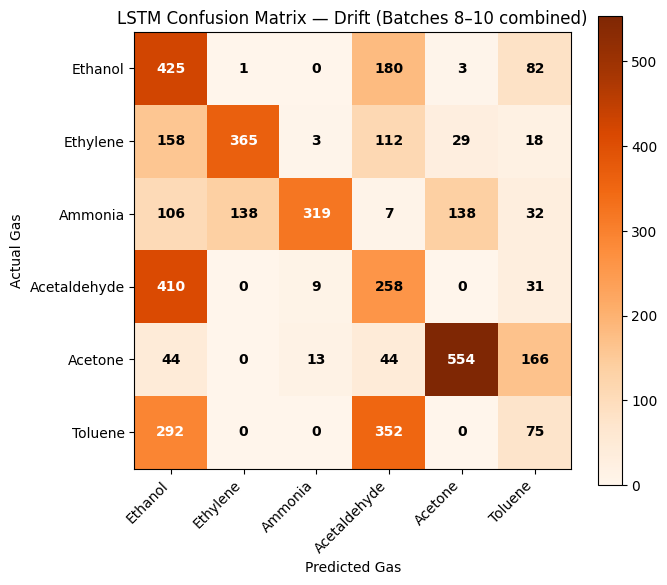

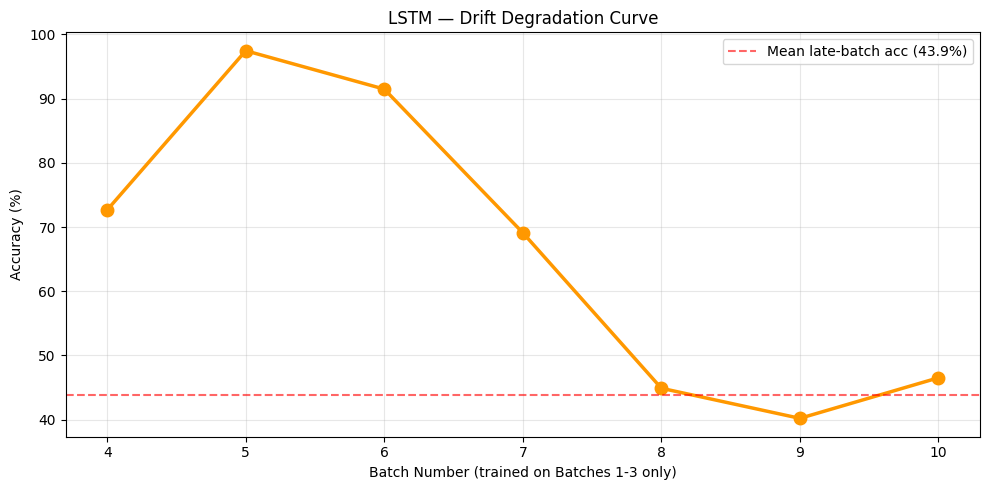

In [35]:
# ============================================================
# LSTM EVALUATION — MIXED-SPLIT + DRIFT
# ============================================================

print("=" * 60)
print("LSTM — MIXED-SPLIT EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# MIXED-SPLIT EVALUATION
# ------------------------------------------------------------
# Use the predefined reporting run (Run 0).
# IMPORTANT:
# The test set is NOT used to select the best run.
# ------------------------------------------------------------

REPORT_RUN_LSTM_MIXED = 0

reported_mixed_preds_lstm = (
    preds_mixed[0][REPORT_RUN_LSTM_MIXED]
)

lstm_mixed_acc = accuracy_score(
    y_test_mixed,
    reported_mixed_preds_lstm
) * 100

print(
    f"LSTM mixed-split accuracy "
    f"(predefined Run {REPORT_RUN_LSTM_MIXED + 1}): "
    f"{lstm_mixed_acc:.2f}%"
)

print(
    f"LSTM mixed-split accuracy over 3 runs: "
    f"{np.mean(accs):.2f}% ± {np.std(accs):.2f}%"
)

print("\nClassification report (predefined reporting run):")

print(
    classification_report(
        y_test_mixed,
        reported_mixed_preds_lstm,
        target_names=GAS_NAMES,
        zero_division=0
    )
)

plot_confusion(
    y_test_mixed,
    reported_mixed_preds_lstm,
    f"LSTM Confusion Matrix — Mixed Split "
    f"(Run {REPORT_RUN_LSTM_MIXED + 1}, "
    f"Acc: {lstm_mixed_acc:.2f}%)",
    "results/lstm_mixed_confusion_matrix.png",
    cmap="Blues"
)


# ============================================================
# LSTM — DRIFT EXPERIMENT EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("LSTM — DRIFT EXPERIMENT EVALUATION")
print("=" * 60)

print_robustness(
    "LSTM (drift)",
    lstm_drift_metrics
)

print(
    f"\nStability across 3 runs "
    f"(mean late-batch acc): "
    f"{np.mean(mean_late_accs_lstm):.2f}% ± "
    f"{np.std(mean_late_accs_lstm):.2f}%"
)

print("\nPer-batch accuracy and macro-F1:")

for b in ALL_TEST_BATCHES:

    print(
        f"  Batch {b:2d}: "
        f"acc={lstm_drift_metrics['per_batch_accuracy'][b]:.2f}%  "
        f"macro-F1={lstm_drift_metrics['per_batch_macro_f1'][b]:.2f}%"
    )


# ------------------------------------------------------------
# FINAL LATE-BATCH CLASSIFICATION REPORT
# Batches 8–10
# ------------------------------------------------------------

y_true_final_lstm = np.concatenate(
    [
        y_true_by_batch_lstm[b]
        for b in FINAL_TEST_BATCHES
    ]
)

y_pred_final_lstm = np.concatenate(
    [
        y_pred_by_batch_lstm[b]
        for b in FINAL_TEST_BATCHES
    ]
)

print(
    f"\nClassification report — "
    f"combined Batches {FINAL_TEST_BATCHES}:"
)

print(
    classification_report(
        y_true_final_lstm,
        y_pred_final_lstm,
        target_names=GAS_NAMES,
        zero_division=0
    )
)


# ------------------------------------------------------------
# DRIFT CONFUSION MATRIX
# ------------------------------------------------------------

plot_confusion(
    y_true_final_lstm,
    y_pred_final_lstm,
    "LSTM Confusion Matrix — Drift "
    "(Batches 8–10 combined)",
    "results/lstm_drift_confusion_matrix.png",
    cmap="Oranges"
)


# ------------------------------------------------------------
# DRIFT DEGRADATION CURVE
# ------------------------------------------------------------

plot_degradation_curve(
    lstm_drift_metrics,
    ALL_TEST_BATCHES,
    "LSTM — Drift Degradation Curve",
    "results/lstm_drift_degradation_curve.png",
    color="#FF9800"
)

>>> TRANSFORMER MIXED-SPLIT TRAINING <<<

RUN 1/3 (seed=42)
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       0.6336     76.45%     0.1987    93.90%
     5       0.0969     97.10%     0.0671    97.81%
    10       0.0557     98.41%     0.0440    98.90%
    15       0.0423     98.79%     0.0295    99.18%
    20       0.0398     98.91%     0.0345    99.18%
    25       0.0331     99.12%     0.0202    99.32%
    30       0.0206     99.41%     0.0307    98.97%
Early stopping at epoch 33 (no improvement for 8 epochs)
Best val loss: 0.0202


RUN 2/3 (seed=43)
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       0.5739     78.97%     0.2061    94.11%
     5       0.0844     97.52%     0.0906    98.22%
    10       0.0679     97.99%     0.0624    98.63%
    15       0.0471     98.62%     0.0514    98.70%
    20       0.0400     98.79%     0.0621    99.11%
E

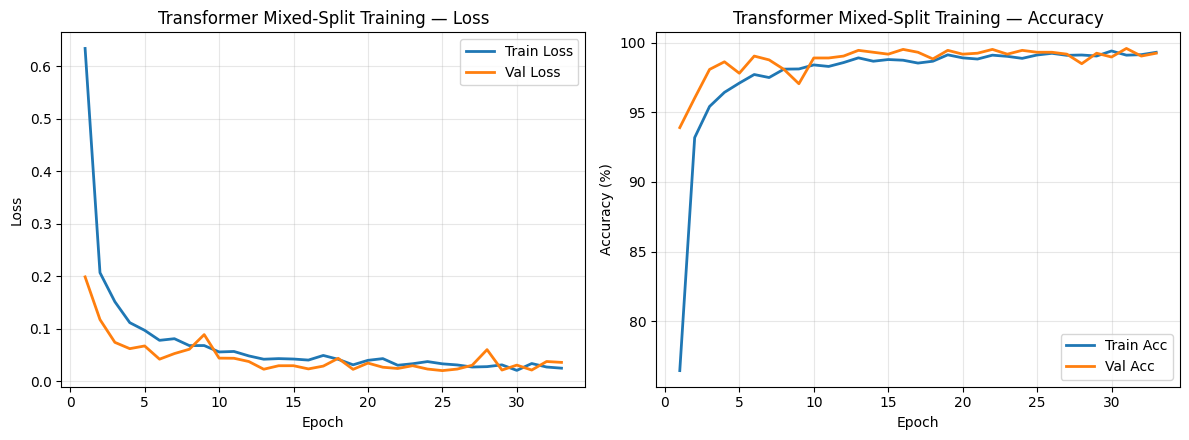


>>> TRANSFORMER DRIFT EXPERIMENT TRAINING <<<

RUN 1/3 (seed=42)
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       0.6719     76.54%     0.1837    96.33%
     5       0.0631     98.24%     0.0336    98.57%
    10       0.0318     99.17%     0.0252    98.78%
    15       0.0416     98.64%     0.0856    98.37%
Early stopping at epoch 19 (no improvement for 8 epochs)
Best val loss: 0.0219


RUN 2/3 (seed=43)
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       0.5979     79.27%     0.2081    93.48%
     5       0.0481     98.71%     0.1226    96.74%
    10       0.0220     99.50%     0.1009    97.35%
Early stopping at epoch 14 (no improvement for 8 epochs)
Best val loss: 0.0505


RUN 3/3 (seed=44)
 Epoch   Train Loss  Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1       0.6051     79.78%     0.1192    95.

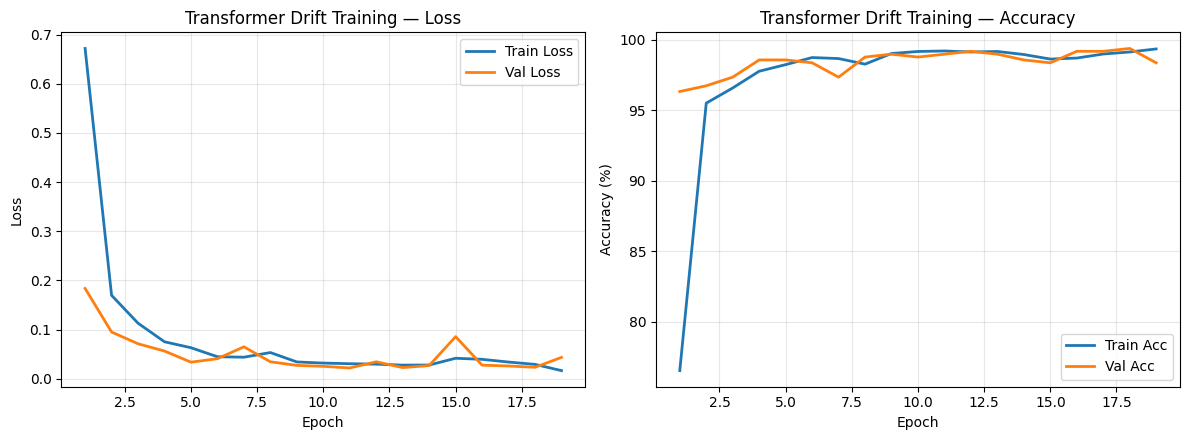

In [36]:
# ============================================================
# TRANSFORMER — TRAINING, same protocol as LSTM
# ============================================================

transformer_kwargs = dict(
    input_dim=8,
    d_model=128,
    nhead=8,
    num_layers=2,
    seq_len=16
)


# ============================================================
# TRANSFORMER — MIXED-SPLIT TRAINING
# ============================================================

set_seed(SEED)

print(">>> TRANSFORMER MIXED-SPLIT TRAINING <<<")

preds_mixed_t, tfm_models_mixed, tfm_histories_mixed = repeated_train_eval(
    GasTransformer,
    X_train_lstm_mixed,
    y_train_mixed,
    {0: X_test_lstm_mixed},
    model_kwargs=transformer_kwargs,
    n_runs=3
)


# ------------------------------------------------------------
# Evaluate all 3 predefined runs.
# Test performance is reported but NOT used for model selection.
# ------------------------------------------------------------

accs_t = [
    accuracy_score(y_test_mixed, p) * 100
    for p in preds_mixed_t[0]
]

print(
    f"\nTransformer mixed-split accuracy over 3 runs: "
    f"{np.mean(accs_t):.2f}% ± {np.std(accs_t):.2f}%"
)


# ------------------------------------------------------------
# PREDEFINED REPORTING RUN
# Run 0 is selected in advance.
# It is NOT selected using held-out test performance.
# ------------------------------------------------------------

REPORT_RUN_TRANSFORMER_MIXED = 0

os.makedirs("models", exist_ok=True)

torch.save(
    tfm_models_mixed[REPORT_RUN_TRANSFORMER_MIXED].state_dict(),
    "models/transformer_mixed_model.pth"
)

plot_training_curves(
    tfm_histories_mixed[REPORT_RUN_TRANSFORMER_MIXED],
    "Transformer Mixed-Split Training",
    "results/transformer_mixed_training_curves.png"
)


# ============================================================
# TRANSFORMER — DRIFT EXPERIMENT
# Training uses Batches 1–3 only
# ============================================================

set_seed(SEED)

print("\n>>> TRANSFORMER DRIFT EXPERIMENT TRAINING <<<")

preds_drift_t, tfm_models_drift, tfm_histories_drift = repeated_train_eval(
    GasTransformer,
    X_train_lstm_drift,
    y_train_lstm_drift,
    X_eval_dict_lstm,
    model_kwargs=transformer_kwargs,
    n_runs=3
)


# ------------------------------------------------------------
# Evaluate each drift run
# ------------------------------------------------------------

run_metrics_t = []

for r in range(3):

    y_pred_r = {
        b: preds_drift_t[b][r]
        for b in ALL_TEST_BATCHES
    }

    m = evaluate_per_batch(
        y_true_by_batch_lstm,
        y_pred_r,
        ALL_TEST_BATCHES
    )

    run_metrics_t.append(m)


# ------------------------------------------------------------
# Mean / SD of late-batch performance across 3 runs
# ------------------------------------------------------------

mean_late_accs_t = [
    m["mean_late_batch_accuracy"]
    for m in run_metrics_t
]


# ------------------------------------------------------------
# PREDEFINED REPORTING RUN
# Run 0 is selected in advance.
# It is NOT selected using held-out test performance.
# ------------------------------------------------------------

REPORT_RUN_TRANSFORMER_DRIFT = 0

y_pred_by_batch_tfm = {
    b: preds_drift_t[b][REPORT_RUN_TRANSFORMER_DRIFT]
    for b in ALL_TEST_BATCHES
}

tfm_drift_metrics = run_metrics_t[
    REPORT_RUN_TRANSFORMER_DRIFT
]

tfm_drift_metrics[
    "mean_late_batch_acc_across_runs"
] = float(
    np.mean(mean_late_accs_t)
)

tfm_drift_metrics[
    "std_late_batch_acc_across_runs"
] = float(
    np.std(mean_late_accs_t)
)


# ------------------------------------------------------------
# SAVE DRIFT MODEL AND METRICS
# ------------------------------------------------------------

os.makedirs("results", exist_ok=True)

torch.save(
    tfm_models_drift[REPORT_RUN_TRANSFORMER_DRIFT].state_dict(),
    "models/transformer_drift_model.pth"
)

with open(
    "results/transformer_drift_metrics.json",
    "w"
) as f:

    json.dump(
        tfm_drift_metrics,
        f,
        default=str,
        indent=2
    )


# ------------------------------------------------------------
# REPORT DRIFT PERFORMANCE
# ------------------------------------------------------------

print(
    f"\nTransformer drift — mean late-batch acc over 3 runs: "
    f"{np.mean(mean_late_accs_t):.2f}% ± "
    f"{np.std(mean_late_accs_t):.2f}%"
)


# ------------------------------------------------------------
# SAVE TRAINING CURVE FOR PREDEFINED DRIFT RUN
# ------------------------------------------------------------

plot_training_curves(
    tfm_histories_drift[REPORT_RUN_TRANSFORMER_DRIFT],
    "Transformer Drift Training",
    "results/transformer_drift_training_curves.png"
)

TRANSFORMER — MIXED-SPLIT EVALUATION
Transformer mixed-split accuracy (predefined Run 1): 98.97%
Transformer mixed-split accuracy over 3 runs: 98.94% ± 0.20%

Classification report (predefined reporting run):
              precision    recall  f1-score   support

     Ethanol       0.99      0.99      0.99       769
    Ethylene       0.99      1.00      0.99       878
     Ammonia       1.00      0.99      0.99       492
Acetaldehyde       1.00      0.96      0.98       581
     Acetone       0.99      1.00      0.99       903
     Toluene       0.97      1.00      0.98       550

    accuracy                           0.99      4173
   macro avg       0.99      0.99      0.99      4173
weighted avg       0.99      0.99      0.99      4173



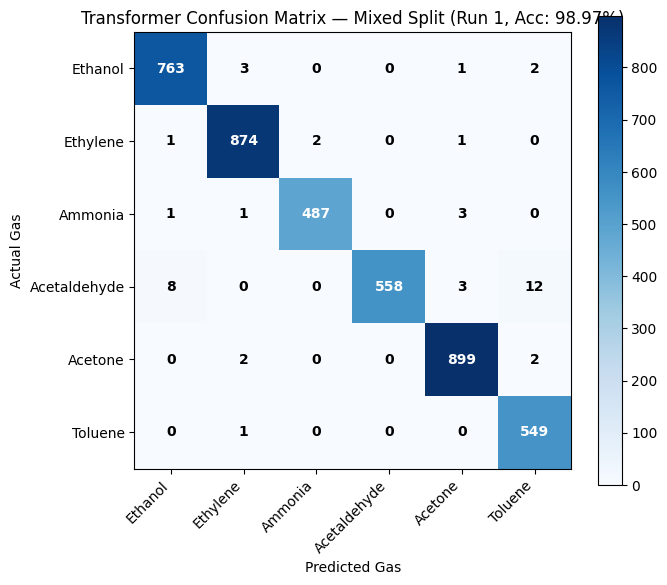


TRANSFORMER — DRIFT EXPERIMENT EVALUATION

--- Robustness summary: Transformer (drift) ---
  Mean late-batch accuracy (8-10): 55.62%
  Worst late-batch accuracy       : 42.39%
  Mean late-batch macro-F1        : 48.70%
  Balanced accuracy (overall)     : 58.43%
  Accuracy drop (best - worst)    : 50.00 pts

Stability across 3 runs (mean late-batch acc): 58.72% ± 5.38%

Per-batch accuracy and macro-F1:
  Batch  4: acc=89.44%  macro-F1=91.14%
  Batch  5: acc=92.39%  macro-F1=91.88%
  Batch  6: acc=74.26%  macro-F1=64.74%
  Batch  7: acc=66.98%  macro-F1=62.41%
  Batch  8: acc=50.00%  macro-F1=37.93%
  Batch  9: acc=74.47%  macro-F1=70.94%
  Batch 10: acc=42.39%  macro-F1=37.22%

Classification report — combined Batches [8, 9, 10]:
              precision    recall  f1-score   support

     Ethanol       0.29      0.53      0.37       691
    Ethylene       0.42      0.86      0.56       685
     Ammonia       0.82      0.22      0.35       740
Acetaldehyde       0.36      0.45      0.40

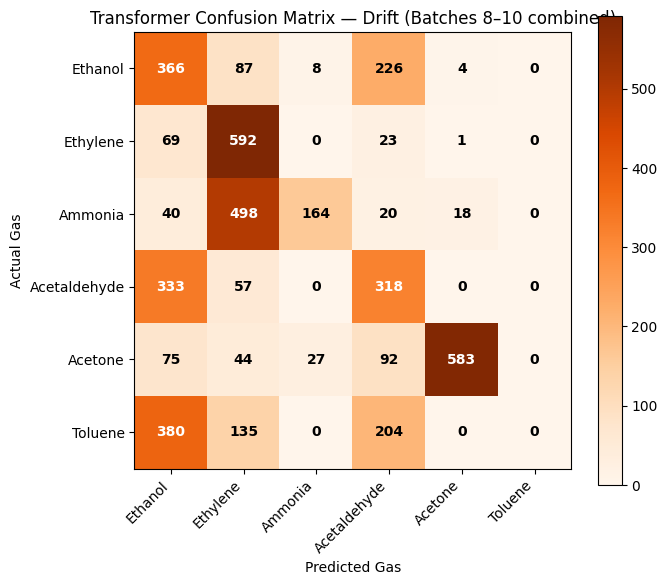

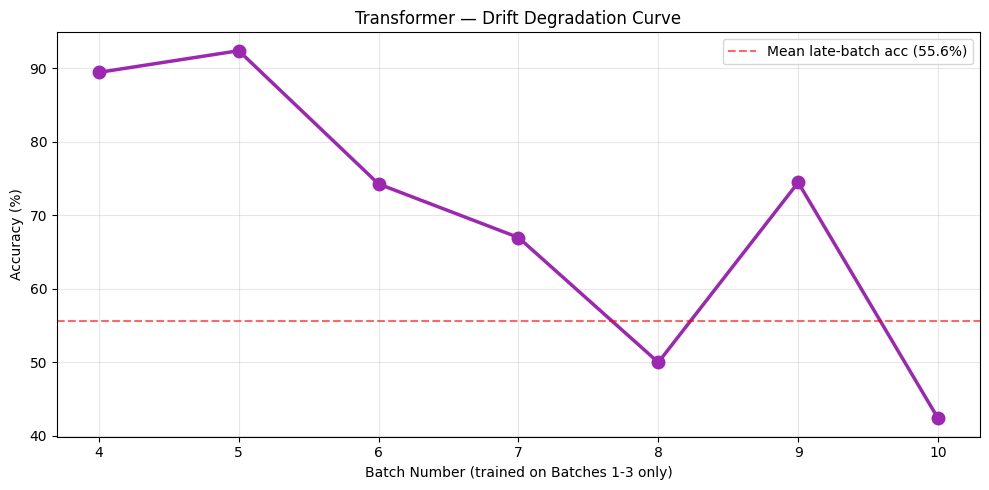

In [37]:
# ============================================================
# TRANSFORMER EVALUATION — MIXED-SPLIT + DRIFT
# ============================================================

print("=" * 60)
print("TRANSFORMER — MIXED-SPLIT EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# MIXED-SPLIT EVALUATION
# Predefined reporting run — NOT selected using test accuracy
# ------------------------------------------------------------
REPORT_RUN_TRANSFORMER_MIXED = 0

reported_mixed_preds_tfm = (
    preds_mixed_t[0][REPORT_RUN_TRANSFORMER_MIXED]
)

tfm_mixed_acc = accuracy_score(
    y_test_mixed,
    reported_mixed_preds_tfm
) * 100

print(
    f"Transformer mixed-split accuracy "
    f"(predefined Run {REPORT_RUN_TRANSFORMER_MIXED + 1}): "
    f"{tfm_mixed_acc:.2f}%"
)

print(
    f"Transformer mixed-split accuracy over 3 runs: "
    f"{np.mean(accs_t):.2f}% ± {np.std(accs_t):.2f}%"
)

print("\nClassification report (predefined reporting run):")

print(
    classification_report(
        y_test_mixed,
        reported_mixed_preds_tfm,
        target_names=GAS_NAMES,
        zero_division=0
    )
)

plot_confusion(
    y_test_mixed,
    reported_mixed_preds_tfm,
    f"Transformer Confusion Matrix — Mixed Split "
    f"(Run {REPORT_RUN_TRANSFORMER_MIXED + 1}, "
    f"Acc: {tfm_mixed_acc:.2f}%)",
    "results/transformer_mixed_confusion_matrix.png",
    cmap="Blues"
)


# ============================================================
# TRANSFORMER — DRIFT EXPERIMENT EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("TRANSFORMER — DRIFT EXPERIMENT EVALUATION")
print("=" * 60)

print_robustness(
    "Transformer (drift)",
    tfm_drift_metrics
)

print(
    f"\nStability across 3 runs "
    f"(mean late-batch acc): "
    f"{np.mean(mean_late_accs_t):.2f}% ± "
    f"{np.std(mean_late_accs_t):.2f}%"
)

print("\nPer-batch accuracy and macro-F1:")

for b in ALL_TEST_BATCHES:
    print(
        f"  Batch {b:2d}: "
        f"acc={tfm_drift_metrics['per_batch_accuracy'][b]:.2f}%  "
        f"macro-F1={tfm_drift_metrics['per_batch_macro_f1'][b]:.2f}%"
    )


# ------------------------------------------------------------
# FINAL LATE-BATCH CLASSIFICATION REPORT
# Batches 8–10
# ------------------------------------------------------------

y_true_final_tfm = np.concatenate(
    [
        y_true_by_batch_lstm[b]
        for b in FINAL_TEST_BATCHES
    ]
)

y_pred_final_tfm = np.concatenate(
    [
        y_pred_by_batch_tfm[b]
        for b in FINAL_TEST_BATCHES
    ]
)

print(
    f"\nClassification report — "
    f"combined Batches {FINAL_TEST_BATCHES}:"
)

print(
    classification_report(
        y_true_final_tfm,
        y_pred_final_tfm,
        target_names=GAS_NAMES,
        zero_division=0
    )
)


# ------------------------------------------------------------
# DRIFT CONFUSION MATRIX
# ------------------------------------------------------------

plot_confusion(
    y_true_final_tfm,
    y_pred_final_tfm,
    "Transformer Confusion Matrix — Drift "
    "(Batches 8–10 combined)",
    "results/transformer_drift_confusion_matrix.png",
    cmap="Oranges"
)


# ------------------------------------------------------------
# DRIFT DEGRADATION CURVE
# ------------------------------------------------------------

plot_degradation_curve(
    tfm_drift_metrics,
    ALL_TEST_BATCHES,
    "Transformer — Drift Degradation Curve",
    "results/transformer_drift_degradation_curve.png",
    color="#9C27B0"
)

In [38]:
# ============================================================
# RESERVOIR COMPUTING — TRAINING (Echo State Network, ReservoirPy)
# ============================================================

!pip install reservoirpy -q

import numpy as np
import os
import json
from reservoirpy.nodes import Reservoir
from sklearn.linear_model import RidgeClassifier
print("ReservoirPy loaded successfully")
# ============================================================
# RESERVOIR STATE EXTRACTION
# ============================================================
def create_reservoir(
    units=200,
    lr=0.3,
    sr=0.9,
    seed=SEED
):
    """
    Create a fresh ReservoirPy reservoir (Echo State Network).

    The reservoir processes the 16 sensor positions,
    where each sensor contains 8 descriptors.

    Shape:
        (16 sensors, 8 descriptors)

    The 16 positions represent sensor structure/order,
    NOT chronological time.
    """

    return Reservoir(
        units=units,
        lr=lr,
        sr=sr,
        seed=seed
    )

def get_reservoir_states(
    X_seq,
    units=200,
    lr=0.3,
    sr=0.9,
    seed=SEED
):
    """
    Convert sensor-descriptor samples into reservoir states.

    Each sample is processed independently using a fresh
    reservoir to prevent state carry-over between samples.
    """
    states = []

    for sample in X_seq:

        # ----------------------------------------------------
        # Fresh reservoir for every independent sample
        # ----------------------------------------------------

        reservoir = create_reservoir(
            units=units,
            lr=lr,
            sr=sr,
            seed=seed
        )
        # ----------------------------------------------------
        # sample shape:
        # (16 sensors, 8 descriptors)
        # ----------------------------------------------------

        reservoir_output = reservoir.run(
            sample
        )
        reservoir_output = np.asarray(
            reservoir_output
        )
        # ----------------------------------------------------
        # Use final reservoir state as sample representation
        # ----------------------------------------------------

        final_state = (
            reservoir_output[-1]
            .reshape(-1)
        )

        states.append(
            final_state
        )

    return np.asarray(
        states,
        dtype=np.float64
    )
# ============================================================
# ESN / RESERVOIR CLASSIFIER
# ============================================================

def run_reservoir_classifier(
    X_train_seq,
    y_train,
    X_eval_dict,
    units=200,
    lr=0.3,
    sr=0.9,
    ridge_alpha=1e-6,
    seed=SEED
):
    # --------------------------------------------------------
    # TRAINING RESERVOIR STATES
    # --------------------------------------------------------
    print(
        "Computing reservoir states for training set..."
    )

    train_states = get_reservoir_states(
        X_train_seq,
        units=units,
        lr=lr,
        sr=sr,
        seed=seed
    )

    print(
        "Training reservoir states shape:",
        train_states.shape
    )
    # --------------------------------------------------------
    # RIDGE READOUT
    # --------------------------------------------------------

    readout = RidgeClassifier(
        alpha=ridge_alpha
    )

    readout.fit(
        train_states,
        y_train
    )

    print(
        "Ridge readout trained."
    )
    # --------------------------------------------------------
    # EVALUATE EACH BATCH
    # --------------------------------------------------------
    predictions_by_batch = {}

    for batch_number, X_batch in X_eval_dict.items():

        print(
            f"Computing reservoir states for "
            f"Batch {batch_number}..."
        )

        eval_states = get_reservoir_states(
            X_batch,
            units=units,
            lr=lr,
            sr=sr,
            seed=seed
        )

        batch_predictions = readout.predict(
            eval_states
        )

        predictions_by_batch[
            batch_number
        ] = batch_predictions

        print(
            f"Batch {batch_number:02d}: "
            f"{len(batch_predictions)} predictions generated"
        )

    return predictions_by_batch

# ============================================================
# TRAIN ESN ON EARLY BATCHES
# ============================================================

print(
    "\nTraining Reservoir Computing model (ESN) on "
    "Batches 1–3..."
)

esn_preds = run_reservoir_classifier(
    X_train_lstm_drift,
    y_train_lstm_drift,
    X_eval_dict_lstm,
    units=200,
    lr=0.3,
    sr=0.9,
    ridge_alpha=1e-6,
    seed=SEED
)

esn_metrics = evaluate_per_batch(y_true_by_batch_lstm, esn_preds, ALL_TEST_BATCHES)

print(
    "\nESN prediction generation completed."
)

ReservoirPy loaded successfully

Training Reservoir Computing model (ESN) on Batches 1–3...
Computing reservoir states for training set...


Running Reservoir-3274: 100%|██████████| 16/16 [00:00<00:00, 5987.59it/s]


Training reservoir states shape: (3275, 200)
Ridge readout trained.
Computing reservoir states for Batch 4...


Running Reservoir-3435: 100%|██████████| 16/16 [00:00<00:00, 4563.37it/s]


Batch 04: 161 predictions generated
Computing reservoir states for Batch 5...


...

Batch 08: 294 predictions generated
Computing reservoir states for Batch 9...


Running Reservoir-10309: 100%|██████████| 16/16 [00:00<00:00, 4770.32it/s]


Batch 09: 470 predictions generated
Computing reservoir states for Batch 10...


Running Reservoir-13909: 100%|██████████| 16/16 [00:00<00:00, 5575.22it/s]


Batch 10: 3600 predictions generated

ESN prediction generation completed.


RESERVOIR COMPUTING (ESN) — DRIFT EXPERIMENT EVALUATION

--- Robustness summary: ESN (drift) ---
  Mean late-batch accuracy (8-10): 54.59%
  Worst late-batch accuracy       : 36.31%
  Mean late-batch macro-F1        : 46.09%
  Balanced accuracy (overall)     : 52.61%
  Accuracy drop (best - worst)    : 44.91 pts

Per-batch accuracy and macro-F1:
  Batch  4: acc=75.78%  macro-F1=82.36%
  Batch  5: acc=81.22%  macro-F1=82.48%
  Batch  6: acc=57.87%  macro-F1=51.83%
  Batch  7: acc=60.70%  macro-F1=57.19%
  Batch  8: acc=72.79%  macro-F1=58.67%
  Batch  9: acc=54.68%  macro-F1=46.54%
  Batch 10: acc=36.31%  macro-F1=33.07%

Classification report — combined Batches [8, 9, 10]:
              precision    recall  f1-score   support

     Ethanol       0.22      0.78      0.34       691
    Ethylene       0.65      0.49      0.56       685
     Ammonia       0.86      0.76      0.81       740
Acetaldehyde       0.36      0.11      0.17       708
     Acetone       0.75      0.32      0.45    

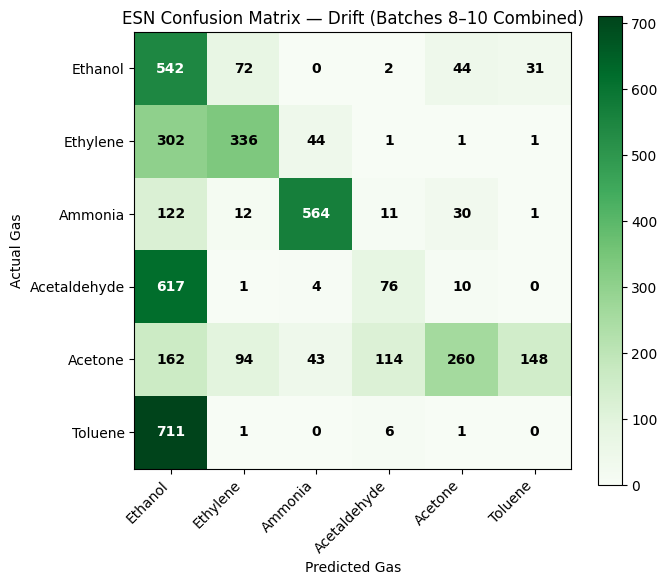

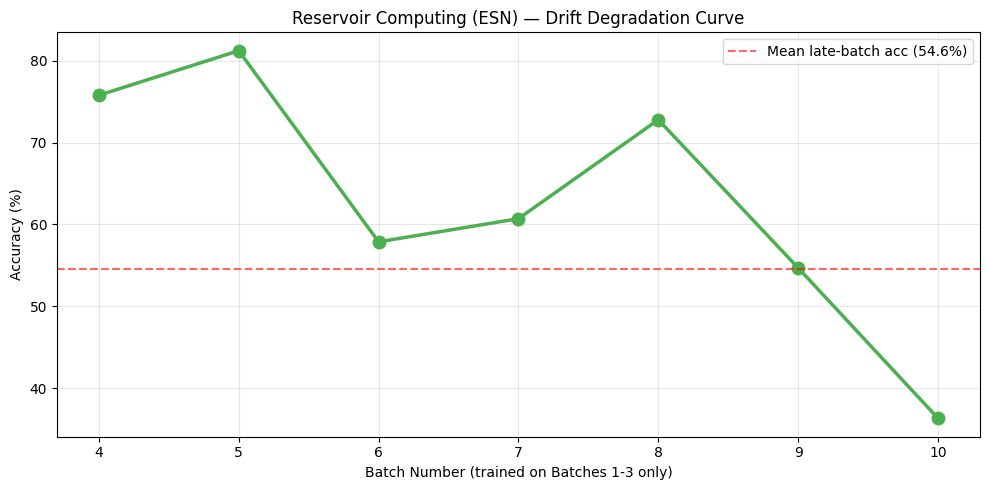


ESN drift evaluation completed successfully.
Confusion matrix saved to: results/esn_drift_confusion_matrix.png
Degradation curve saved to: results/esn_drift_degradation_curve.png


In [39]:
# ============================================================
# ESN EVALUATION — DRIFT EXPERIMENT
# ============================================================

print("=" * 60)
print("RESERVOIR COMPUTING (ESN) — DRIFT EXPERIMENT EVALUATION")
print("=" * 60)

print_robustness(
    "ESN (drift)",
    esn_metrics
)

print(
    "\nPer-batch accuracy and macro-F1:"
)
for b in ALL_TEST_BATCHES:
    print(
        f"  Batch {b:2d}: "
        f"acc={esn_metrics['per_batch_accuracy'][b]:.2f}%  "
        f"macro-F1={esn_metrics['per_batch_macro_f1'][b]:.2f}%"
    )

y_true_final_esn = np.concatenate(
    [
        y_true_by_batch_lstm[b]
        for b in FINAL_TEST_BATCHES
    ]
)

y_pred_final_esn = np.concatenate(
    [
        esn_preds[b]
        for b in FINAL_TEST_BATCHES
    ]
)

print(
    f"\nClassification report — "
    f"combined Batches {FINAL_TEST_BATCHES}:"
)

print(
    classification_report(
        y_true_final_esn,
        y_pred_final_esn,
        target_names=GAS_NAMES,
        zero_division=0
    )
)

plot_confusion(
    y_true_final_esn,
    y_pred_final_esn,
    "ESN Confusion Matrix — Drift (Batches 8–10 Combined)",
    "results/esn_drift_confusion_matrix.png",
    cmap="Greens"
)

plot_degradation_curve(
    esn_metrics,
    ALL_TEST_BATCHES,
    "Reservoir Computing (ESN) — Drift Degradation Curve",
    "results/esn_drift_degradation_curve.png",
    color="#4CAF50"
)

print(
    "\nESN drift evaluation completed successfully."
)

print(
    "Confusion matrix saved to: "
    "results/esn_drift_confusion_matrix.png"
)

print(
    "Degradation curve saved to: "
    "results/esn_drift_degradation_curve.png"
)

            Model  Mixed-split Acc  Mean Late-Batch Acc  Worst Late-Batch Acc  Mean Late-Batch Macro-F1  Balanced Acc (overall)  Accuracy Drop
              SVM            99.35                61.18                 40.83                     51.42                   60.64          54.09
             LSTM            98.67                43.88                 40.21                     38.53                   63.07          57.25
      Transformer            98.94                55.62                 42.39                     48.70                   58.43          50.00
ESN (ReservoirPy)              NaN                54.59                 36.31                     46.09                   52.61          44.91


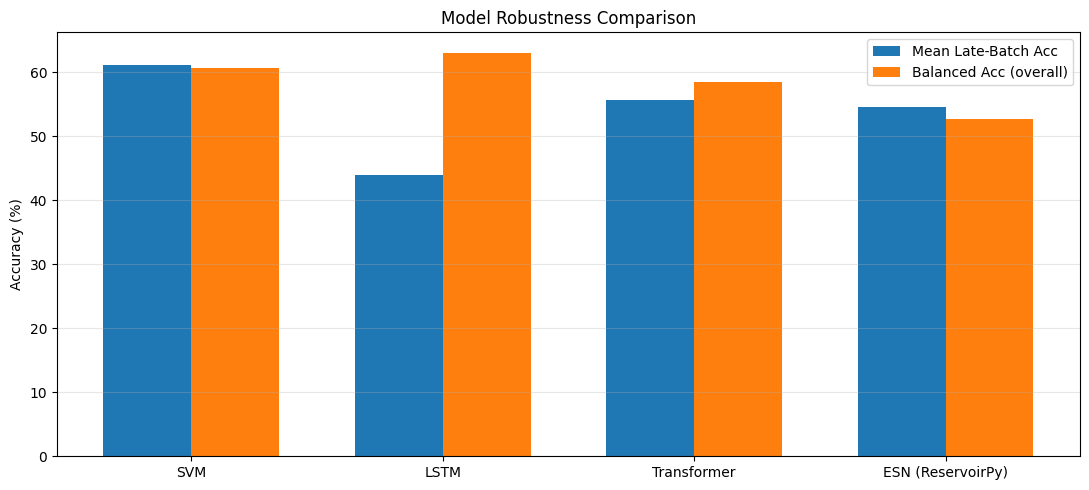

In [40]:
# ============================================================
# FINAL COMPARISON TABLE — SVM, LSTM, Transformer, ESN
# ============================================================
comparison = pd.DataFrame([
    {"Model": "SVM",         "Mixed-split Acc": svm_mixed_acc,
     "Mean Late-Batch Acc": svm_drift_metrics["mean_late_batch_accuracy"],
     "Worst Late-Batch Acc": svm_drift_metrics["worst_late_batch_accuracy"],
     "Mean Late-Batch Macro-F1": svm_drift_metrics["mean_late_batch_macro_f1"],
     "Balanced Acc (overall)": svm_drift_metrics["balanced_accuracy_overall"],
     "Accuracy Drop": svm_drift_metrics["accuracy_drop"]},
    {"Model": "LSTM",        "Mixed-split Acc": np.mean(accs),
     "Mean Late-Batch Acc": lstm_drift_metrics["mean_late_batch_accuracy"],
     "Worst Late-Batch Acc": lstm_drift_metrics["worst_late_batch_accuracy"],
     "Mean Late-Batch Macro-F1": lstm_drift_metrics["mean_late_batch_macro_f1"],
     "Balanced Acc (overall)": lstm_drift_metrics["balanced_accuracy_overall"],
     "Accuracy Drop": lstm_drift_metrics["accuracy_drop"]},
    {"Model": "Transformer", "Mixed-split Acc": np.mean(accs_t),
     "Mean Late-Batch Acc": tfm_drift_metrics["mean_late_batch_accuracy"],
     "Worst Late-Batch Acc": tfm_drift_metrics["worst_late_batch_accuracy"],
     "Mean Late-Batch Macro-F1": tfm_drift_metrics["mean_late_batch_macro_f1"],
     "Balanced Acc (overall)": tfm_drift_metrics["balanced_accuracy_overall"],
     "Accuracy Drop": tfm_drift_metrics["accuracy_drop"]},
    {"Model": "ESN (ReservoirPy)", "Mixed-split Acc": np.nan,
     "Mean Late-Batch Acc": esn_metrics["mean_late_batch_accuracy"],
     "Worst Late-Batch Acc": esn_metrics["worst_late_batch_accuracy"],
     "Mean Late-Batch Macro-F1": esn_metrics["mean_late_batch_macro_f1"],
     "Balanced Acc (overall)": esn_metrics["balanced_accuracy_overall"],
     "Accuracy Drop": esn_metrics["accuracy_drop"]},
])
comparison = comparison.round(2)
print(comparison.to_string(index=False))

os.makedirs("results", exist_ok=True)
comparison.to_csv("results/model_comparison_table.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison["Mean Late-Batch Acc"], width, label="Mean Late-Batch Acc")
ax.bar(x + width/2, comparison["Balanced Acc (overall)"], width, label="Balanced Acc (overall)")
ax.set_xticks(x); ax.set_xticklabels(comparison["Model"])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Robustness Comparison")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("results/robustness_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [41]:
# ============================================================
# MODEL FEASIBILITY — MODEL SIZE, ONNX EXPORT, LATENCY
# ============================================================

!pip install -q skl2onnx onnx onnxruntime onnxscript

import os
import json
import time
import numpy as np
import torch
import onnx
import onnxruntime as ort
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("=" * 60)
print("MODEL FEASIBILITY ANALYSIS")
print("=" * 60)

# ============================================================
# SVM ONNX EXPORT
# ============================================================

print("\nExporting SVM to ONNX...")

initial_type = [
    ("input", FloatTensorType([None, 128]))
]

onnx_svm = convert_sklearn(
    svm_drift,
    initial_types=initial_type
)

svm_onnx_path = "models/svm_drift.onnx"

with open(svm_onnx_path, "wb") as f:
    f.write(onnx_svm.SerializeToString())

onnx_svm_model = onnx.load(svm_onnx_path)
onnx.checker.check_model(onnx_svm_model)

svm_onnx_size_kb = (
    os.path.getsize(svm_onnx_path) / 1024
)

print("SVM ONNX exported successfully.")
print(f"SVM ONNX size: {svm_onnx_size_kb:.1f} KB")


# ============================================================
# LSTM ONNX EXPORT
# ============================================================

TINYML_LSTM_RUN = 0

best_lstm_model = (
    lstm_models_drift[TINYML_LSTM_RUN]
    .to("cpu")
    .eval()
)

print(
    f"\nUsing LSTM drift run "
    f"{TINYML_LSTM_RUN + 1} "
    f"for model feasibility analysis."
)

print("\nExporting LSTM to ONNX...")

dummy_input = torch.randn(
    1,
    16,
    8,
    dtype=torch.float32
)

lstm_onnx_path = "models/lstm_drift.onnx"

torch.onnx.export(
    best_lstm_model,
    dummy_input,
    lstm_onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    dynamo=False
)

onnx_lstm_model = onnx.load(lstm_onnx_path)
onnx.checker.check_model(onnx_lstm_model)

lstm_onnx_size_kb = (
    os.path.getsize(lstm_onnx_path) / 1024
)

print("LSTM ONNX exported successfully.")
print(f"LSTM ONNX size: {lstm_onnx_size_kb:.1f} KB")


# ============================================================
# ONNX CPU LATENCY BENCHMARK
# ============================================================

def benchmark_onnx_latency(
    onnx_path,
    sample_input,
    n_runs=200
):

    session = ort.InferenceSession(
        onnx_path,
        providers=["CPUExecutionProvider"]
    )

    input_name = session.get_inputs()[0].name

    # Warm-up
    for _ in range(10):
        session.run(
            None,
            {input_name: sample_input}
        )

    start = time.time()

    for _ in range(n_runs):
        session.run(
            None,
            {input_name: sample_input}
        )

    elapsed = time.time() - start

    return (
        elapsed / n_runs * 1000
    )


# ============================================================
# INPUT PREPARATION
# ============================================================

svm_sample = (
    scaler_drift
    .transform(X_all[:1])
    .astype(np.float32)
)

lstm_sample = (
    svm_sample
    .reshape(1, 16, 8)
    .astype(np.float32)
)

print("\nSVM sample shape:", svm_sample.shape)
print("LSTM sample shape:", lstm_sample.shape)


# ============================================================
# LATENCY TESTING
# ============================================================

print("\nBenchmarking ONNX Runtime CPU latency...")

svm_latency_ms = benchmark_onnx_latency(
    svm_onnx_path,
    svm_sample,
    n_runs=200
)

lstm_latency_ms = benchmark_onnx_latency(
    lstm_onnx_path,
    lstm_sample,
    n_runs=200
)

print(
    f"\nSVM ONNX latency: "
    f"{svm_latency_ms:.3f} ms"
)

print(
    f"LSTM ONNX latency: "
    f"{lstm_latency_ms:.3f} ms"
)


# ============================================================
# MODEL SIZE COMPARISON
# ============================================================

print("\nModel size comparison:")
print(f"SVM: {svm_onnx_size_kb:.1f} KB")
print(f"LSTM: {lstm_onnx_size_kb:.1f} KB")


if svm_onnx_size_kb < lstm_onnx_size_kb:
    smaller_model = "SVM"
else:
    smaller_model = "LSTM"


if svm_latency_ms < lstm_latency_ms:
    faster_model = "SVM"
else:
    faster_model = "LSTM"


# ============================================================
# MODEL FEASIBILITY REPORT
# ============================================================

if (
    smaller_model == "SVM"
    and faster_model == "SVM"
):
    recommendation = "SVM"
elif (
    smaller_model == "LSTM"
    and faster_model == "LSTM"
):
    recommendation = "LSTM"
else:
    recommendation = faster_model


model_feasibility_report = {

    "svm_onnx_size_kb":
        round(
            svm_onnx_size_kb,
            1
        ),

    "lstm_onnx_size_kb":
        round(
            lstm_onnx_size_kb,
            1
        ),

    "svm_latency_ms":
        round(
            svm_latency_ms,
            3
        ),

    "lstm_latency_ms":
        round(
            lstm_latency_ms,
            3
        ),

    "smaller_model":
        smaller_model,

    "faster_model":
        faster_model,

    "recommendation":
        recommendation,

    "latency_environment":
        "Desktop CPU using ONNX Runtime",

    "input_representation":
        "16 sensors × 8 descriptors",

    "temporal_interpretation":
        "Sensor positions are structural, not chronological time steps"
}


# ============================================================
# DISPLAY REPORT
# ============================================================

print("\n" + "=" * 60)
print("MODEL FEASIBILITY REPORT")
print("=" * 60)

print(
    json.dumps(
        model_feasibility_report,
        indent=2
    )
)


# ============================================================
# SAVE REPORT
# ============================================================

model_feasibility_report_path = (
    "results/model_feasibility_report.json"
)

with open(
    model_feasibility_report_path,
    "w"
) as f:

    json.dump(
        model_feasibility_report,
        f,
        indent=2
    )

print(
    "\nModel feasibility report saved to:"
)

print(
    model_feasibility_report_path
)

MODEL FEASIBILITY ANALYSIS

Exporting SVM to ONNX...
SVM ONNX exported successfully.
SVM ONNX size: 163.6 KB

Using LSTM drift run 1 for model feasibility analysis.

Exporting LSTM to ONNX...


/tmp/ipykernel_1923/1591277618.py:84: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


LSTM ONNX exported successfully.
LSTM ONNX size: 209.6 KB

SVM sample shape: (1, 128)
LSTM sample shape: (1, 16, 8)

Benchmarking ONNX Runtime CPU latency...

SVM ONNX latency: 0.232 ms
LSTM ONNX latency: 0.163 ms

Model size comparison:
SVM: 163.6 KB
LSTM: 209.6 KB

MODEL FEASIBILITY REPORT
{
  "svm_onnx_size_kb": 163.6,
  "lstm_onnx_size_kb": 209.6,
  "svm_latency_ms": 0.232,
  "lstm_latency_ms": 0.163,
  "smaller_model": "SVM",
  "faster_model": "LSTM",
  "recommendation": "LSTM",
  "latency_environment": "Desktop CPU using ONNX Runtime",
  "input_representation": "16 sensors \u00d7 8 descriptors",
  "temporal_interpretation": "Sensor positions are structural, not chronological time steps"
}

Model feasibility report saved to:
results/model_feasibility_report.json


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4463: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


In [43]:
  # ============================================================
# FINAL SAVE
# ============================================================
final_summary = {
    "svm_mixed_split_accuracy": svm_mixed_acc,
    "lstm_mixed_split_accuracy_mean_std": [float(np.mean(accs)), float(np.std(accs))],
    "transformer_mixed_split_accuracy_mean_std": [float(np.mean(accs_t)), float(np.std(accs_t))],
    "svm_drift_metrics": {k: v for k, v in svm_drift_metrics.items() if "per_batch" not in k},
    "lstm_drift_metrics": {k: v for k, v in lstm_drift_metrics.items() if "per_batch" not in k},
    "transformer_drift_metrics": {k: v for k, v in tfm_drift_metrics.items() if "per_batch" not in k},
    "esn_drift_metrics": {k: v for k, v in esn_metrics.items() if "per_batch" not in k},
}

os.makedirs("results", exist_ok=True)
with open("results/final_summary.json", "w") as f:
    json.dump(final_summary, f, default=str, indent=2)

with open("requirements.txt", "w") as f:
    f.write(
        "numpy==1.26.4\n"
        "pandas==2.2.2\n"
        "scikit-learn==1.5.2\n"
        "torch==2.4.1\n"
        "matplotlib==3.9.2\n"
        "scipy==1.13.1\n"
        "reservoirpy==0.3.11\n"
        "skl2onnx==1.17.0\n"
        "onnx==1.16.2\n"
        "onnxruntime==1.19.2\n"
        "joblib==1.4.2\n"
    )

print("Saved: models/ (scalers, .pkl, .pth, .onnx) and results/ (*.json, *.csv, *.png)")
print("\nAll experiments complete: SVM, LSTM, Transformer, ESN (Reservoir Computing) — each evaluated")
print("separately (mixed-split + drift) with a final robustness comparison,")
print("plus a measured TinyML feasibility report.")

Saved: models/ (scalers, .pkl, .pth, .onnx) and results/ (*.json, *.csv, *.png)

All experiments complete: SVM, LSTM, Transformer, ESN (Reservoir Computing) — each evaluated
separately (mixed-split + drift) with a final robustness comparison,
plus a measured TinyML feasibility report.
